In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, confusion_matrix, accuracy_score, classification_report, roc_auc_score

In [3]:
df = pd.read_csv("./creditcard.csv")

## 1. Understanding the dataset

In [4]:
df.shape

(284807, 31)

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
# making a copy of the original dataframe so that original data is not lost
dfcopy = df.copy()
dfcopy.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
dfcopy.drop_duplicates(inplace=True)

In [11]:
dfcopy.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
dfcopy["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

The data is already preprocessed so will directly jump on the EDA and see if any pattern/relation is present in the data

## 2. Outlier Analysis

In [15]:
iqr_counts = {}

for col in dfcopy.select_dtypes(include='float64'):
    Q1 = dfcopy[col].quantile(0.25)
    Q3 = dfcopy[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    iqr_counts[col] = int(((dfcopy[col] < lower_limit) | (dfcopy[col] > upper_limit)).sum())

pd.DataFrame({ "Iqr counts": iqr_counts })

,Iqr counts
Time,0
V1,6948
V2,13390
V3,3306
V4,11094
V5,12221
V6,22886
V7,8839
V8,23904
V9,8199


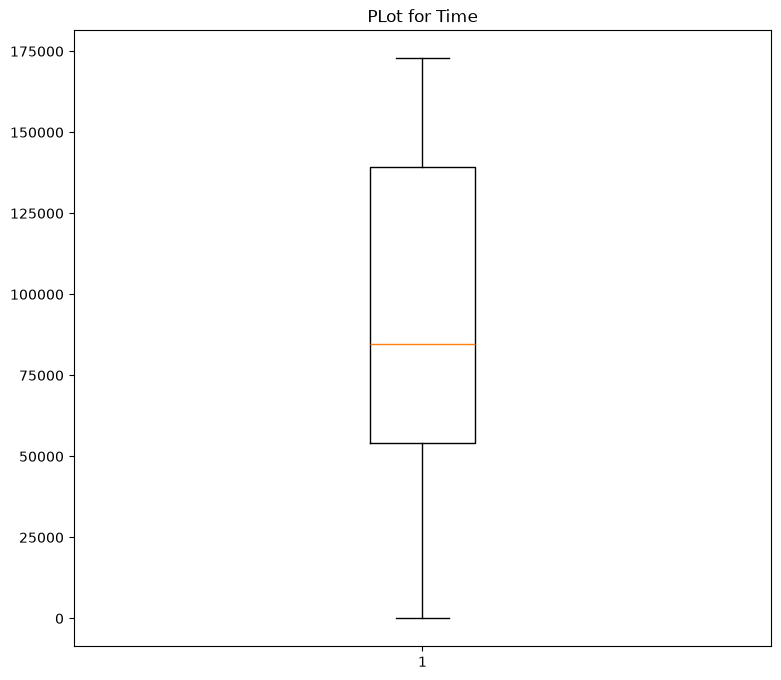

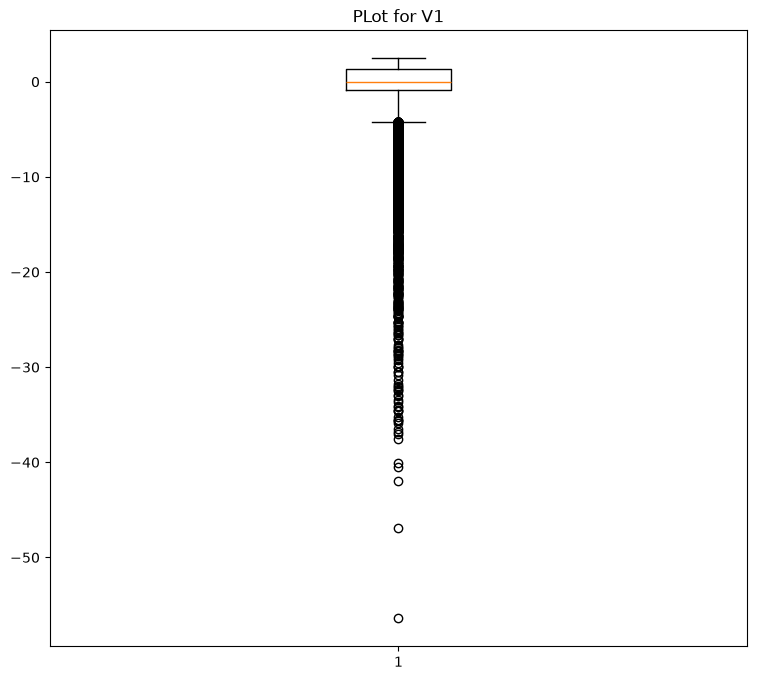

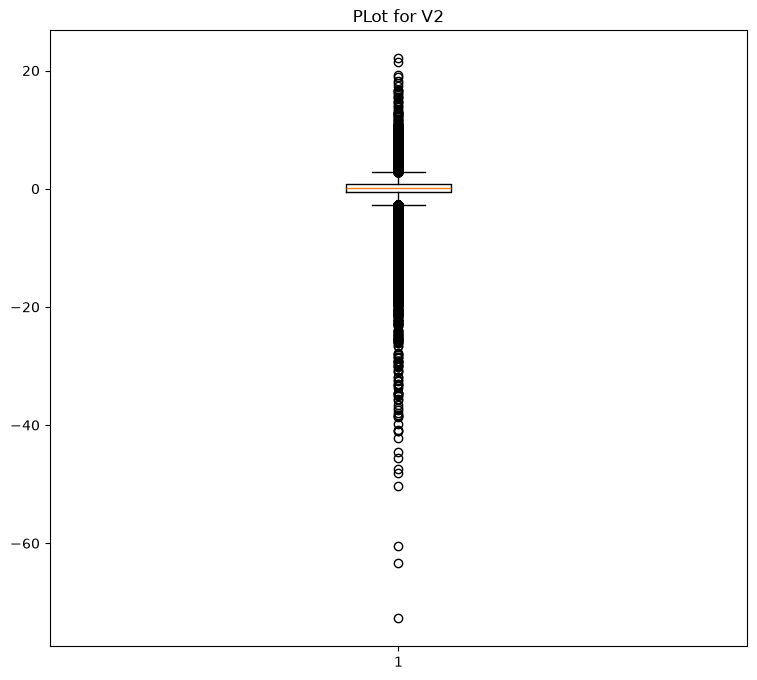

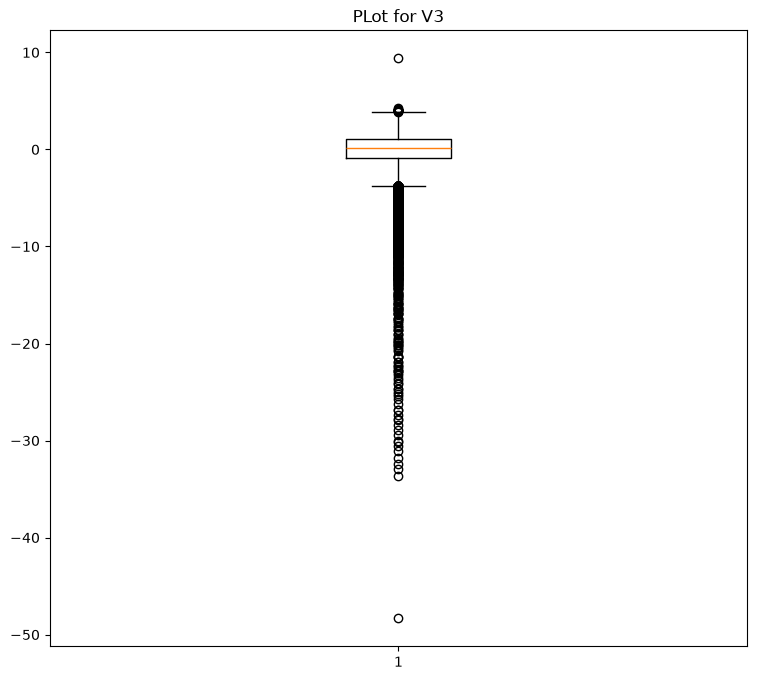

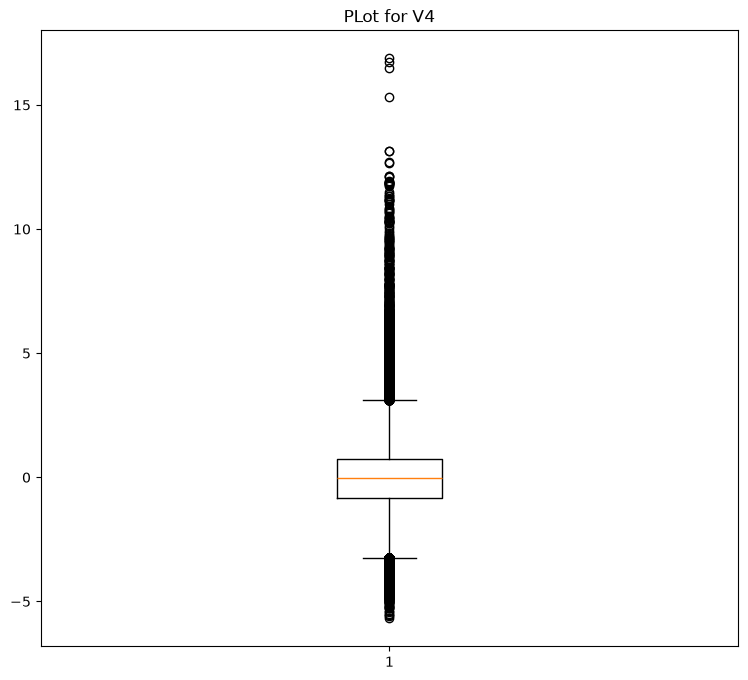

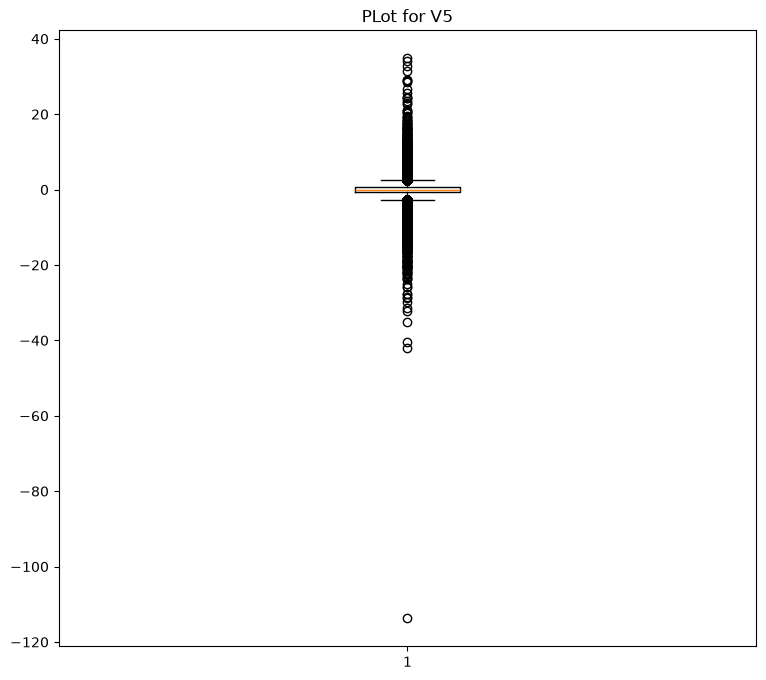

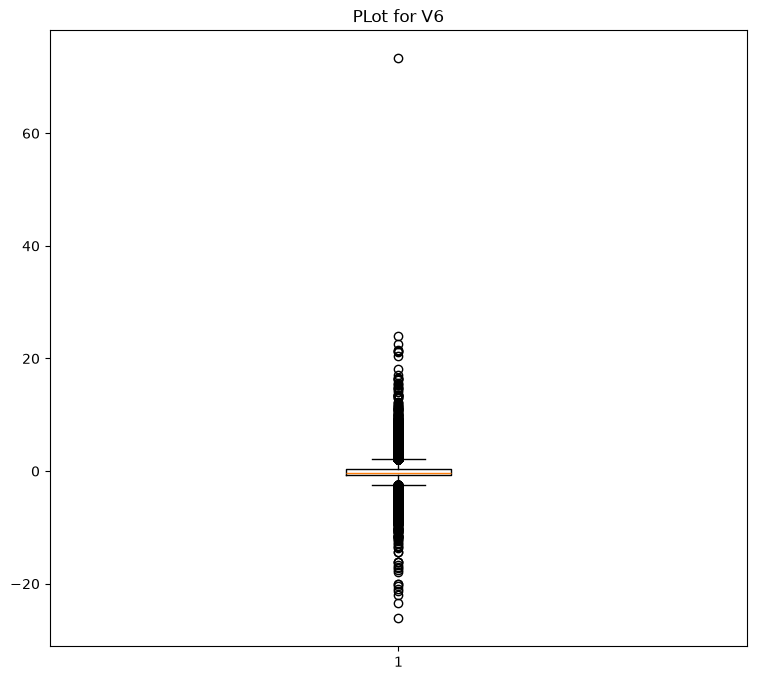

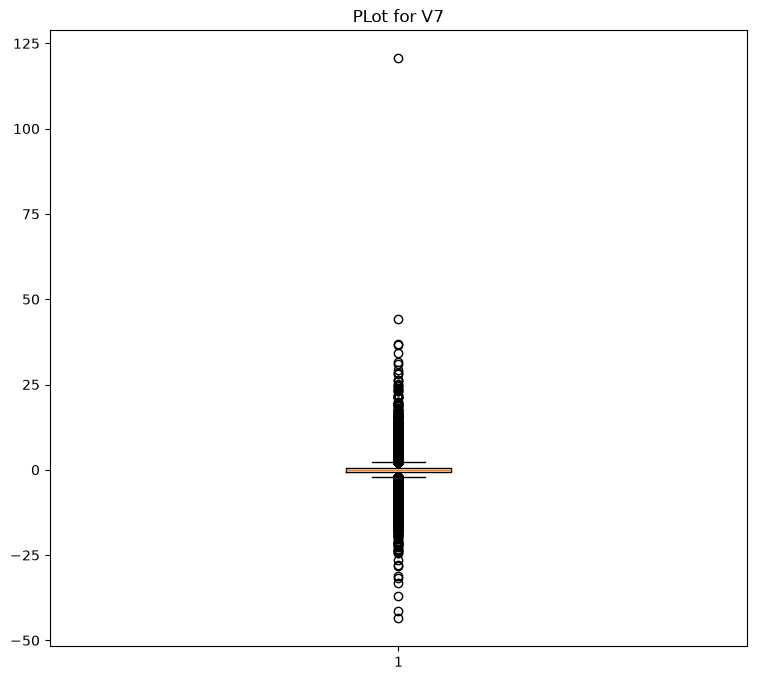

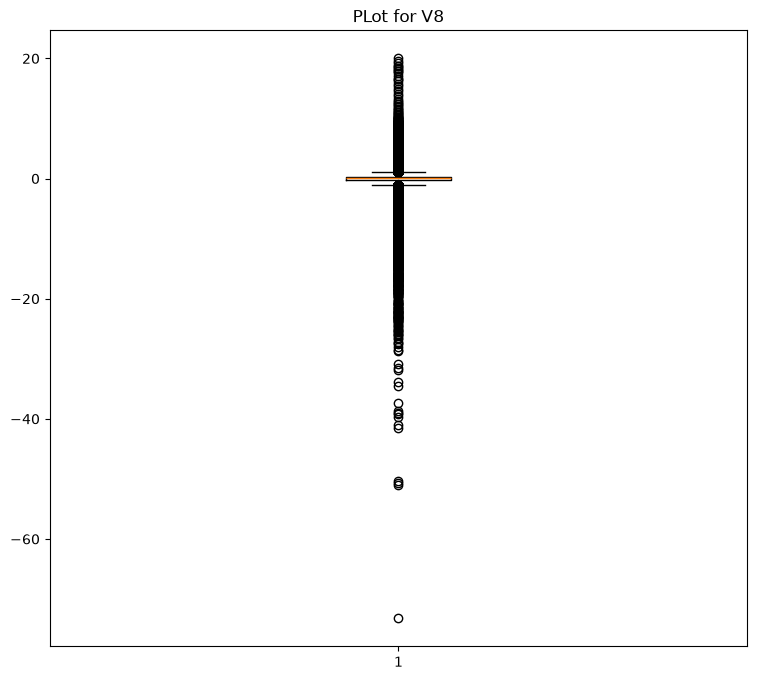

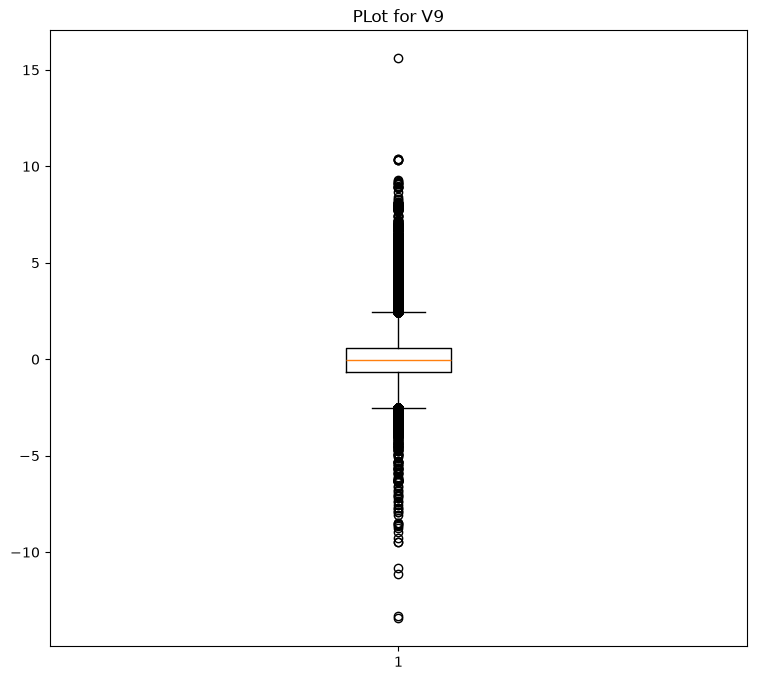

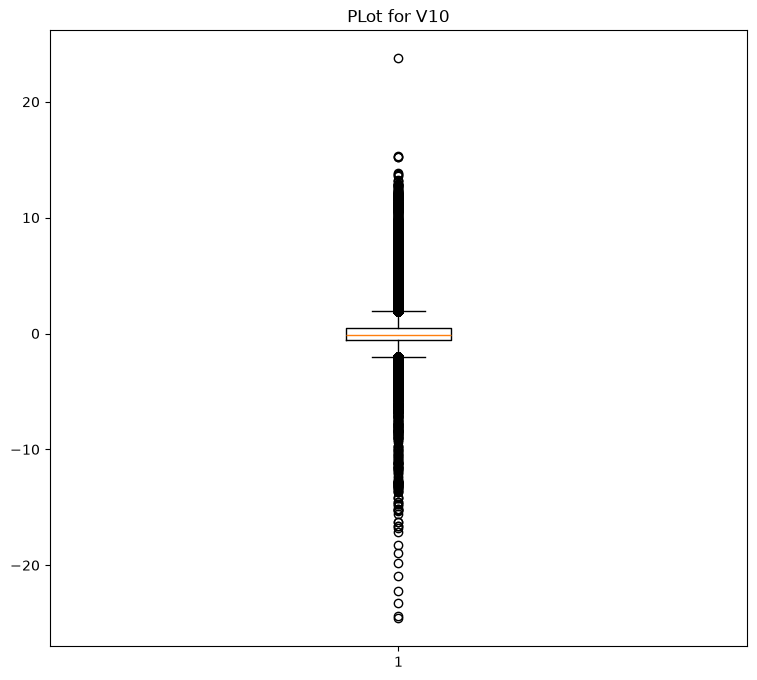

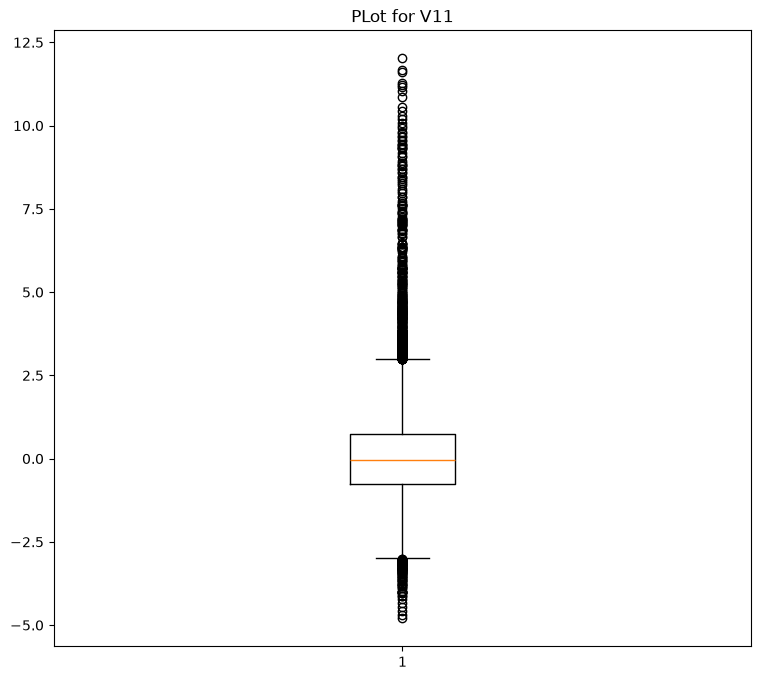

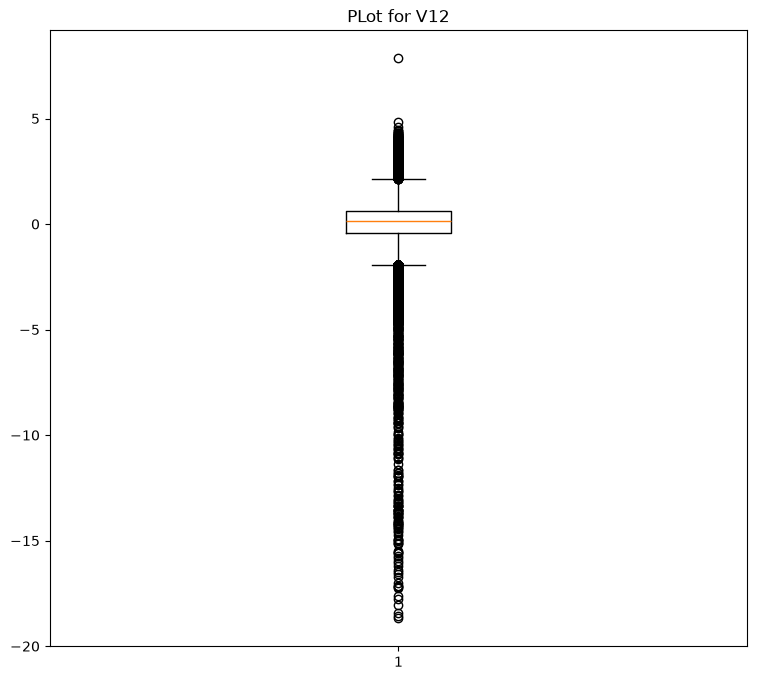

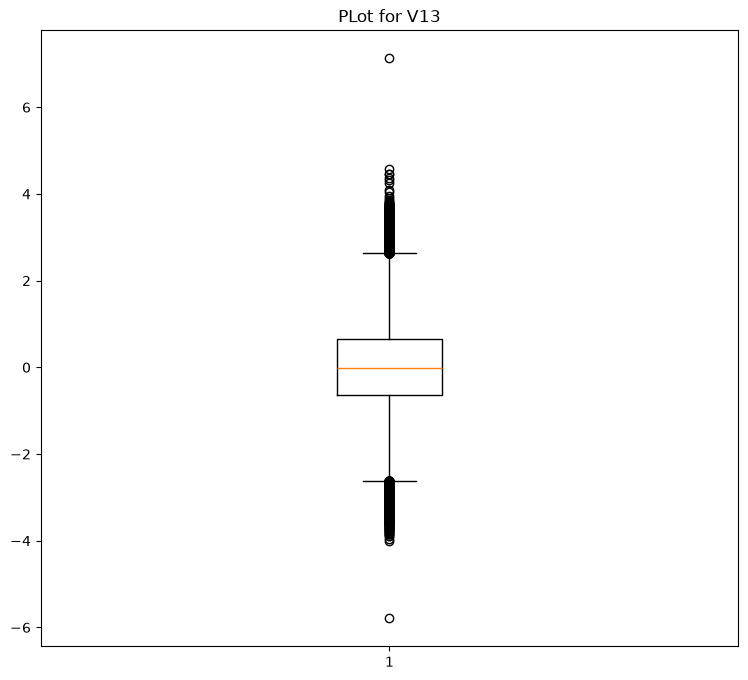

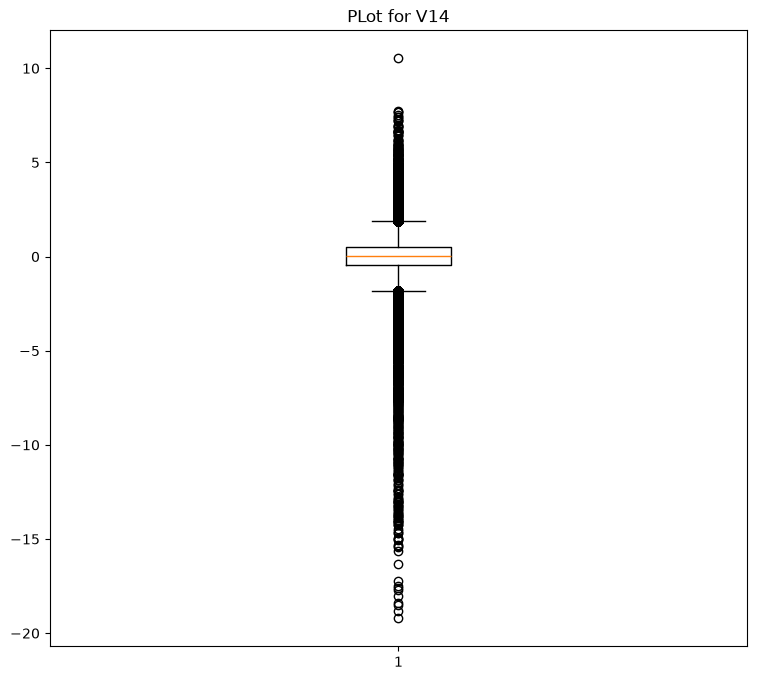

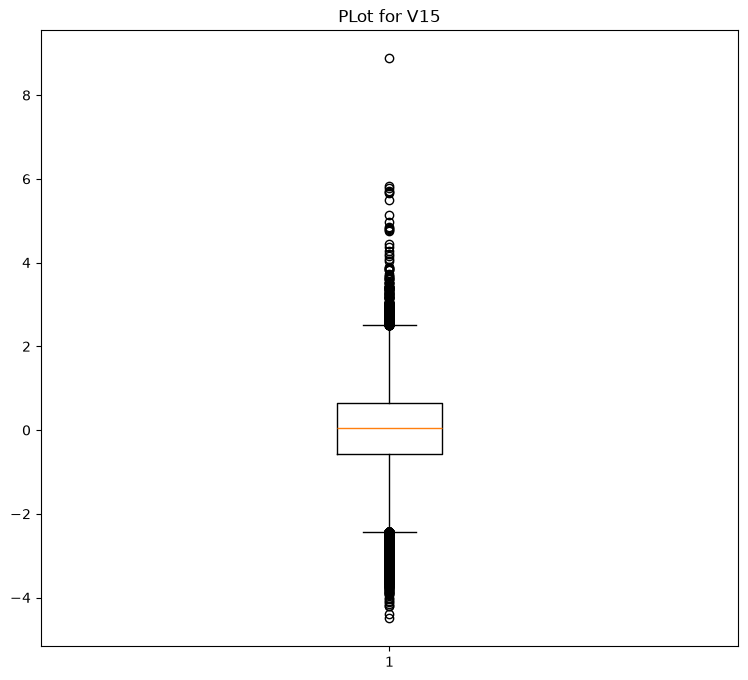

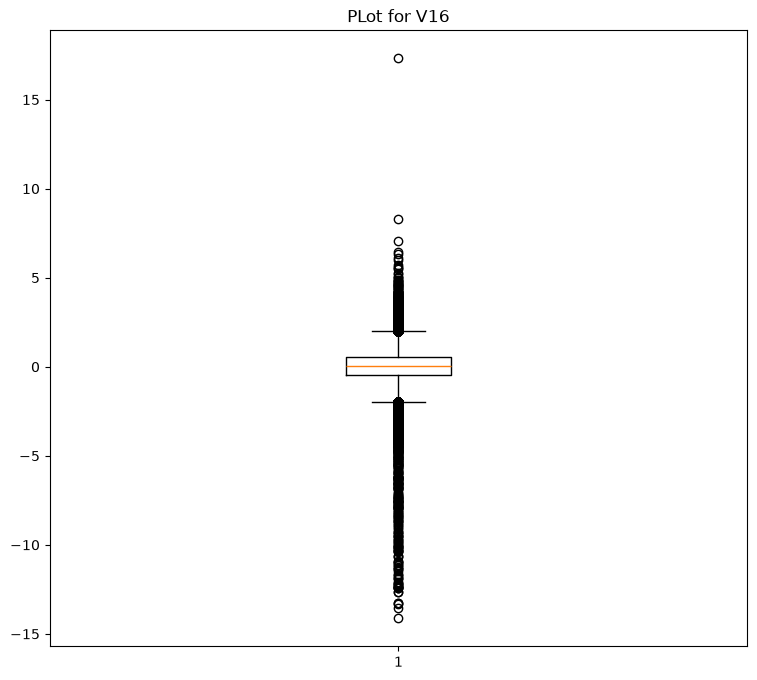

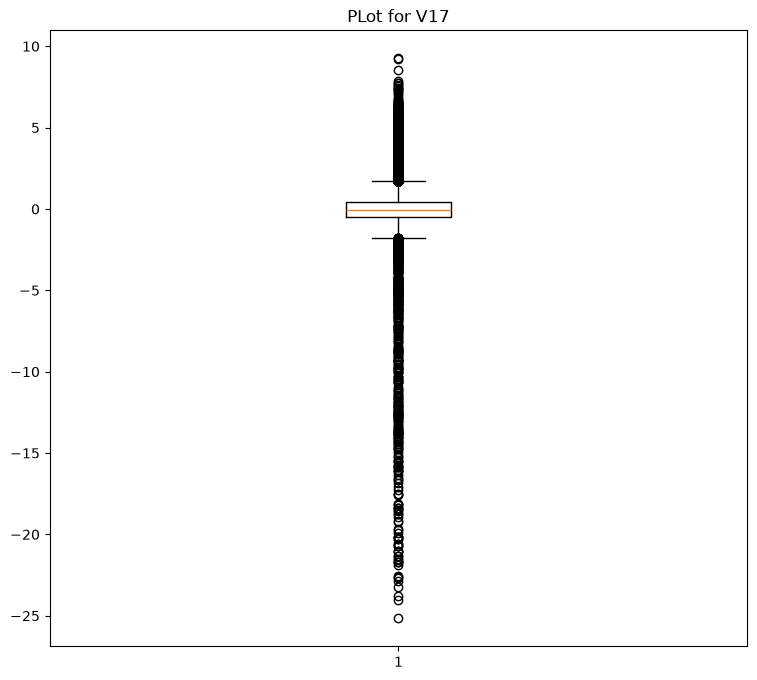

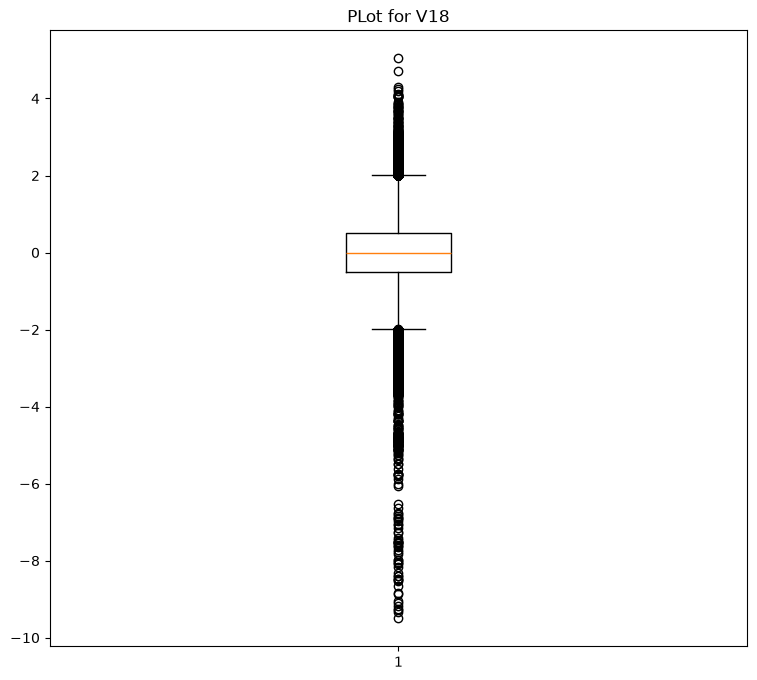

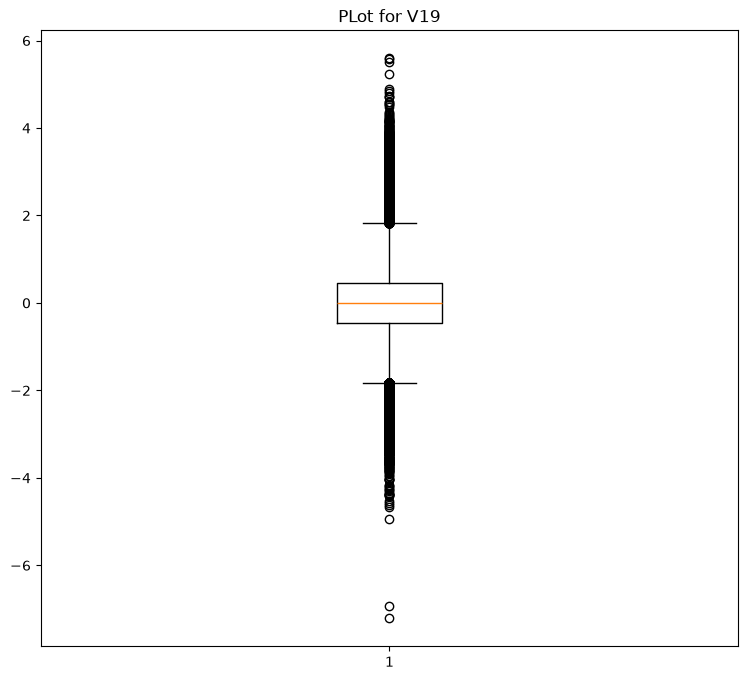

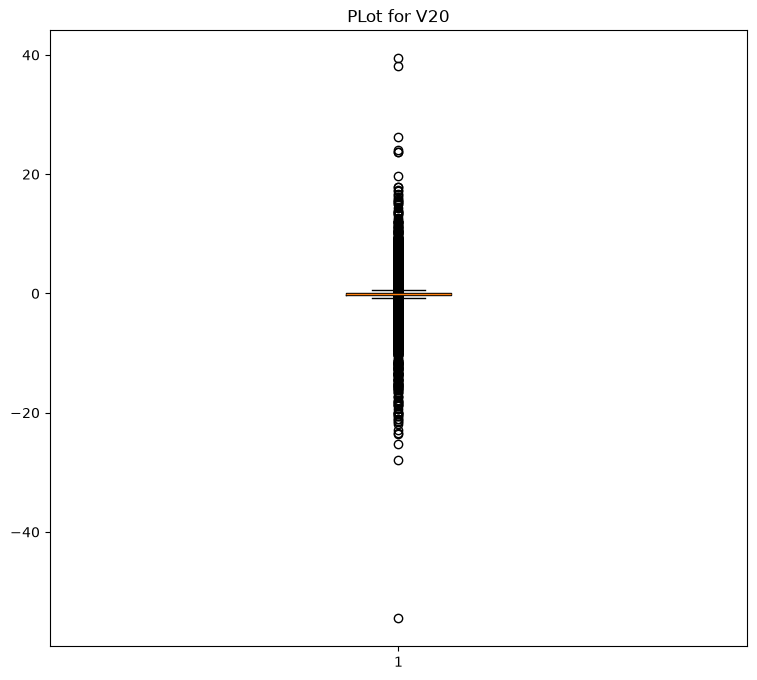

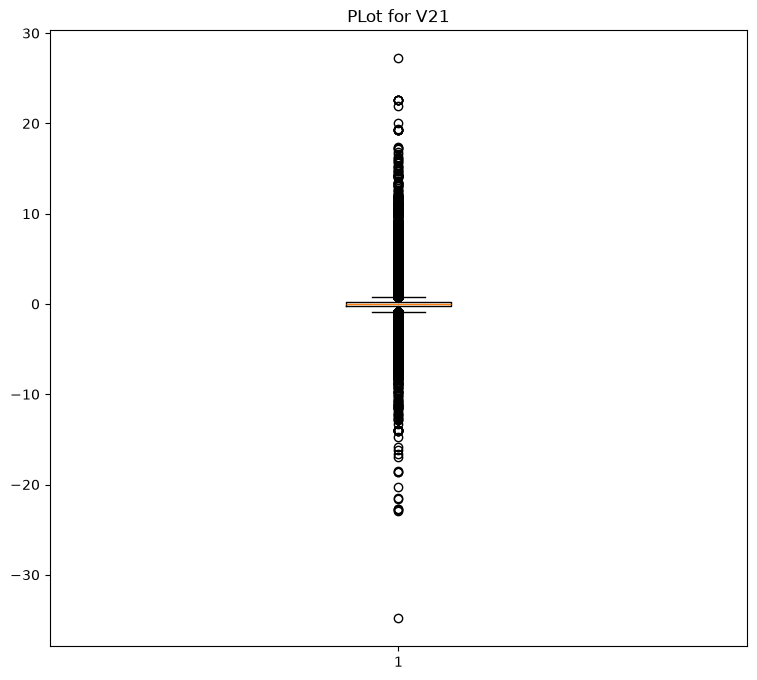

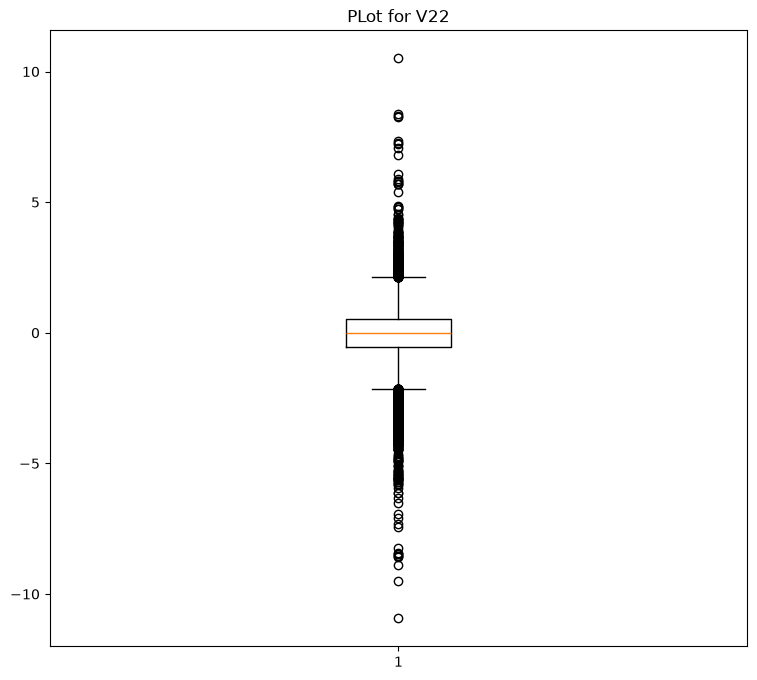

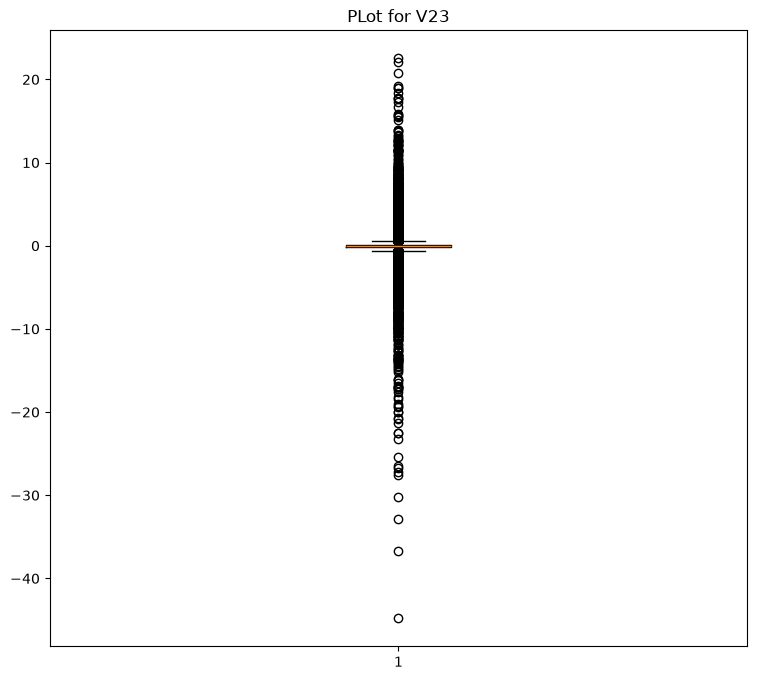

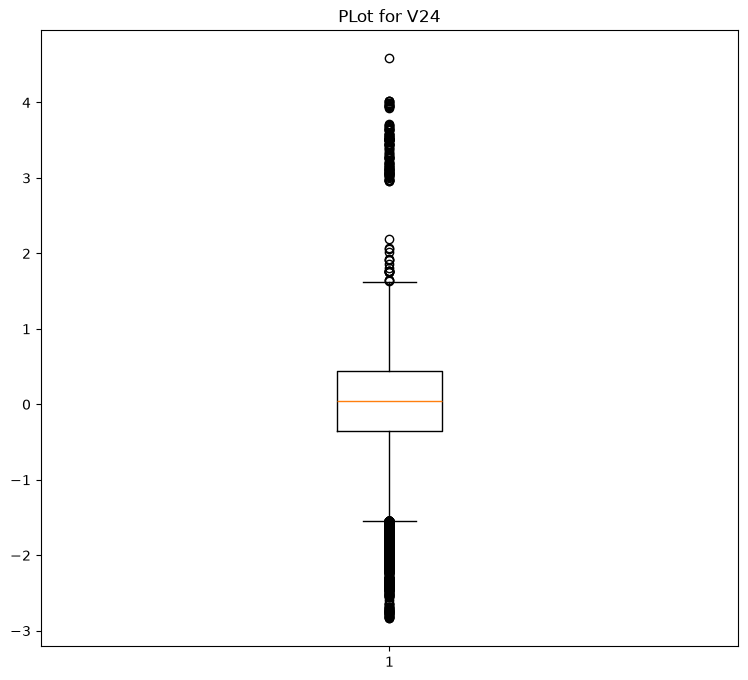

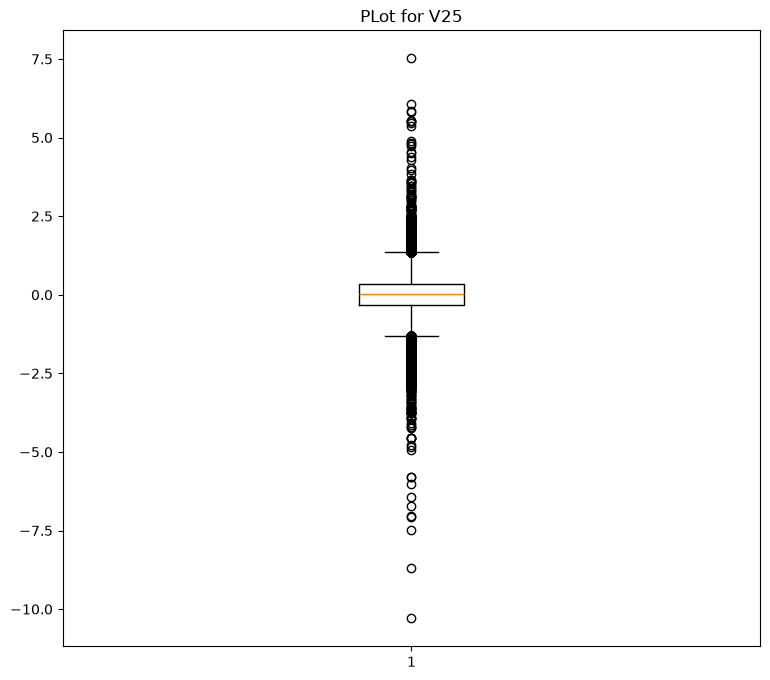

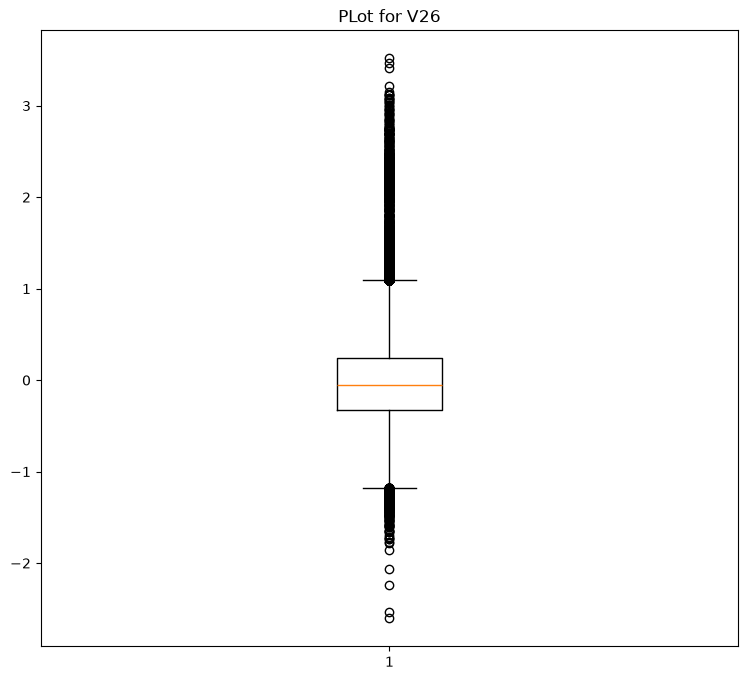

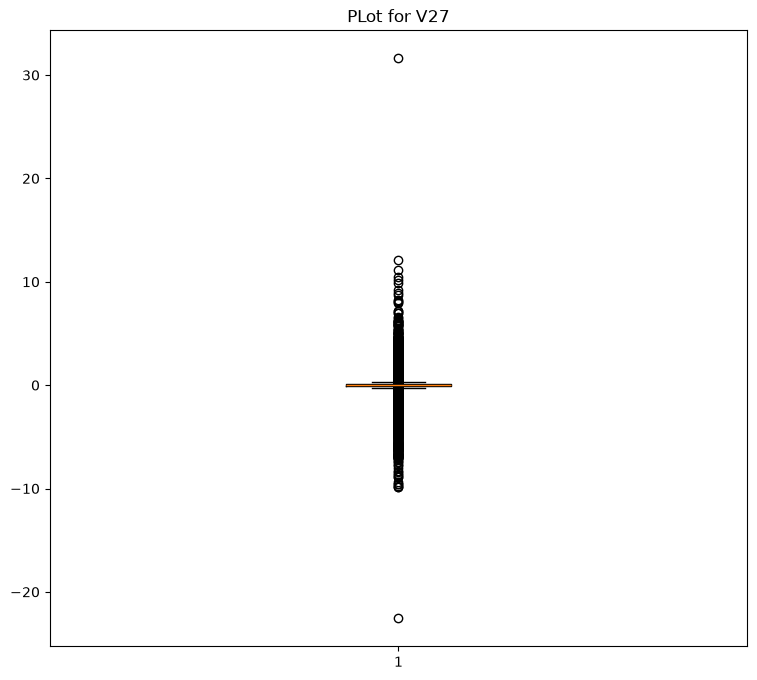

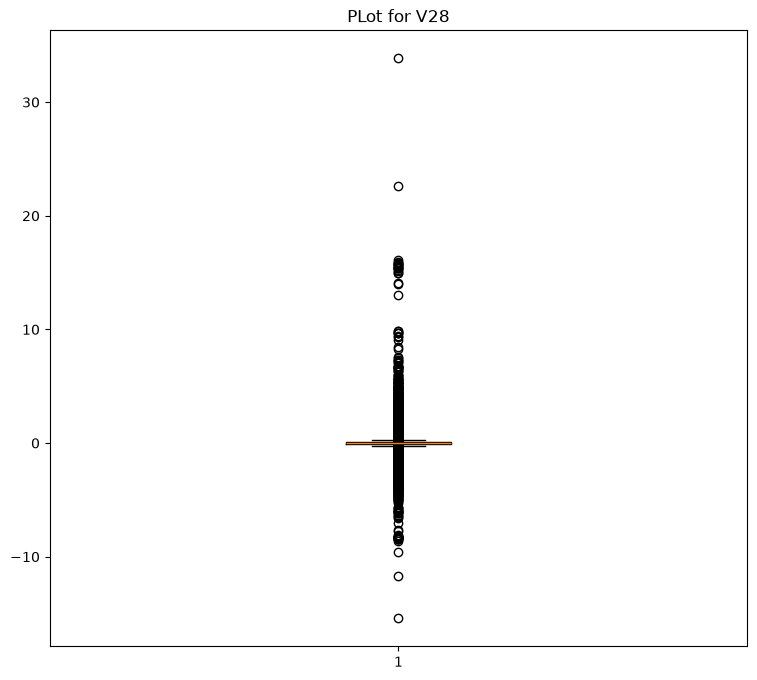

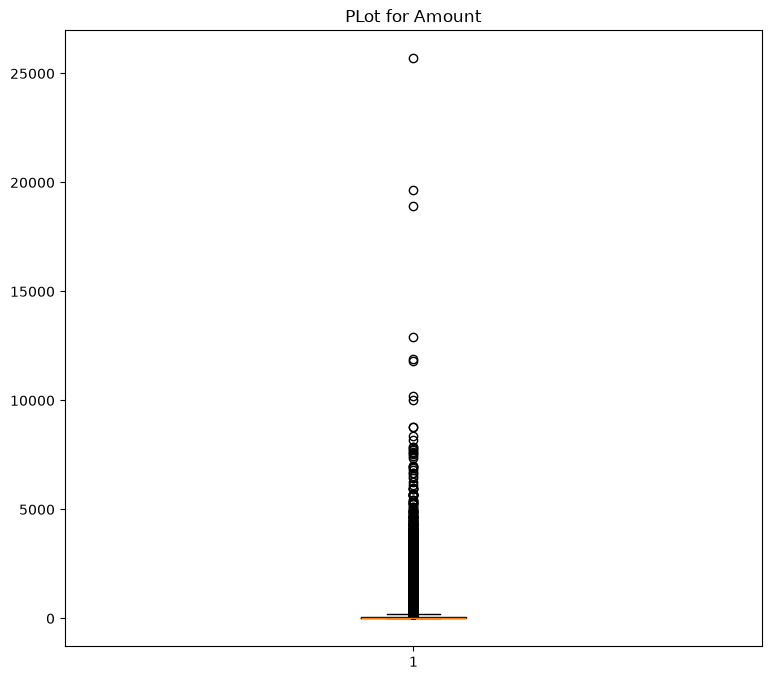

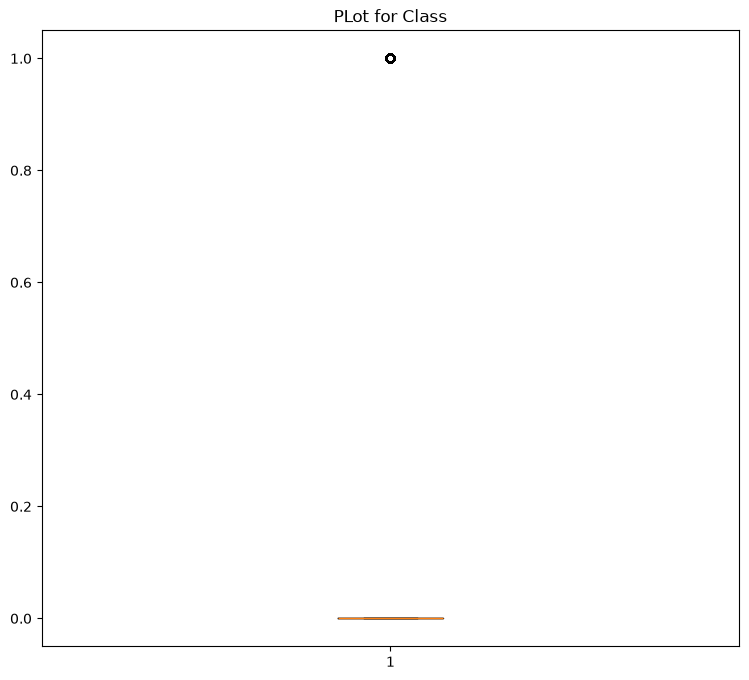

In [16]:
for col in dfcopy.columns:
    plt.figure(figsize=(9,8))
    plt.boxplot(x=dfcopy[col])
    plt.title(f"PLot for {col}")
    plt.show()

Based on the observation of the outliers there will be 2 dataset and this 2 datasets will be used separately to train and take a look at the model and after the model metrics analysis the conclusion for the dataset will be seen. The first dataset will be ***dfcopy*** (copy of original dataset) and the second one will be ***df_trimmed*** (after handling outliers)

In [17]:
df_trimmed = dfcopy.copy()

In [18]:
df_trimmed.shape

(283726, 31)

In [19]:
# Capping the outliers and inside the df_trimmed copy of the dataset

for col in df_trimmed.select_dtypes(include="float64"):
    Q1 = df_trimmed[col].quantile(0.25)
    Q3 = df_trimmed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_trimmed[col] = np.where(
        df_trimmed[col] > upper_limit, upper_limit,
        np.where(df_trimmed[col] < lower_limit, lower_limit, df_trimmed[col])
    )

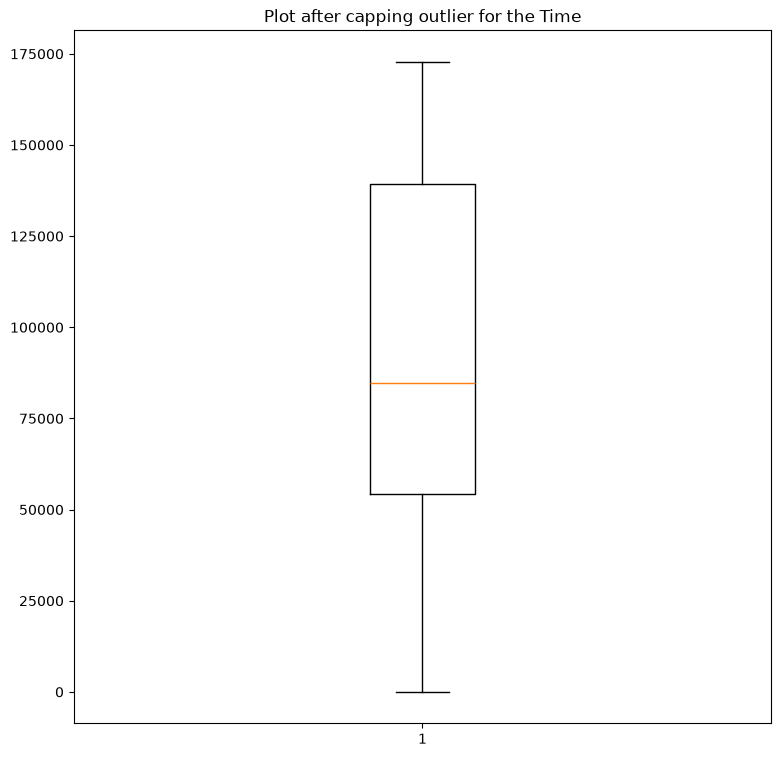

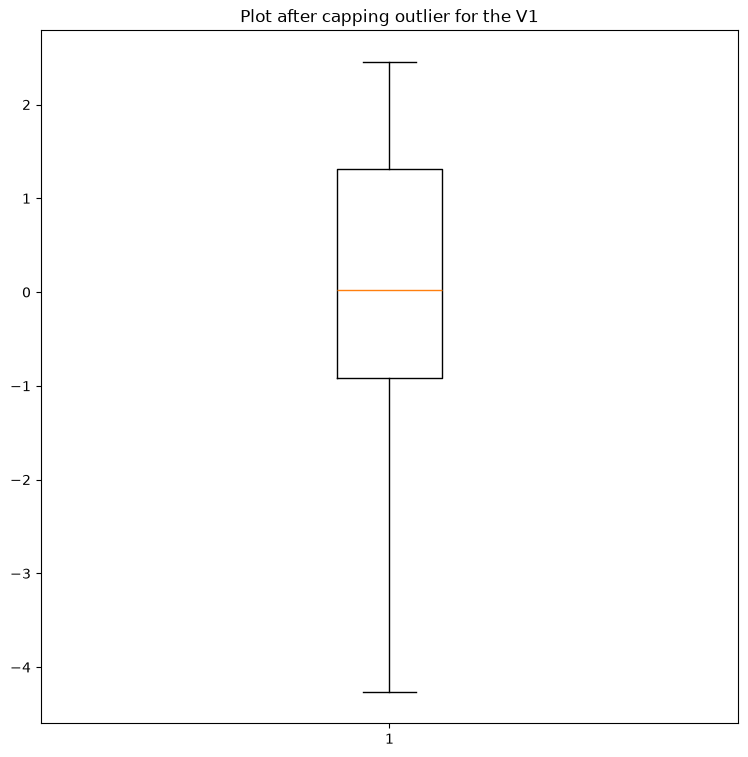

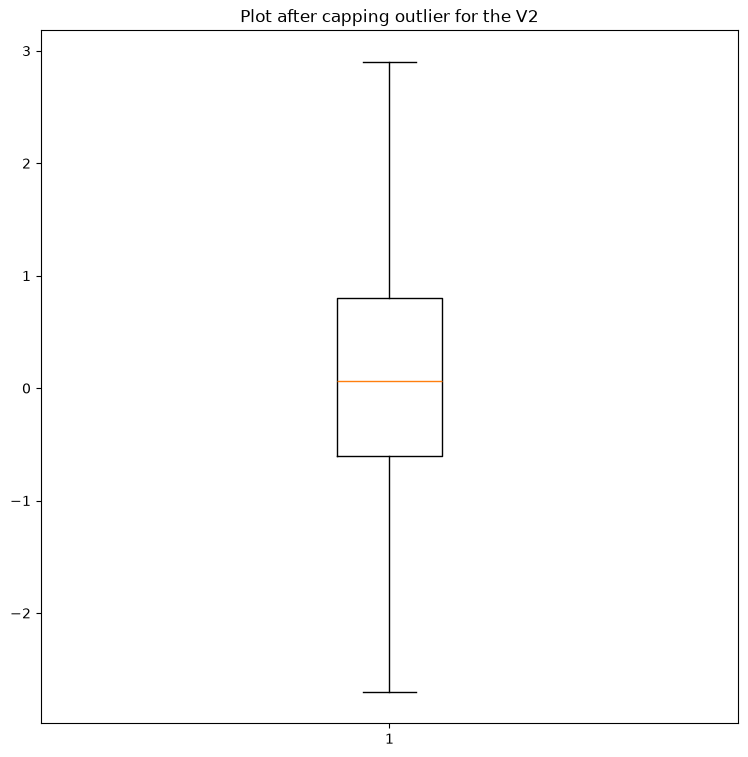

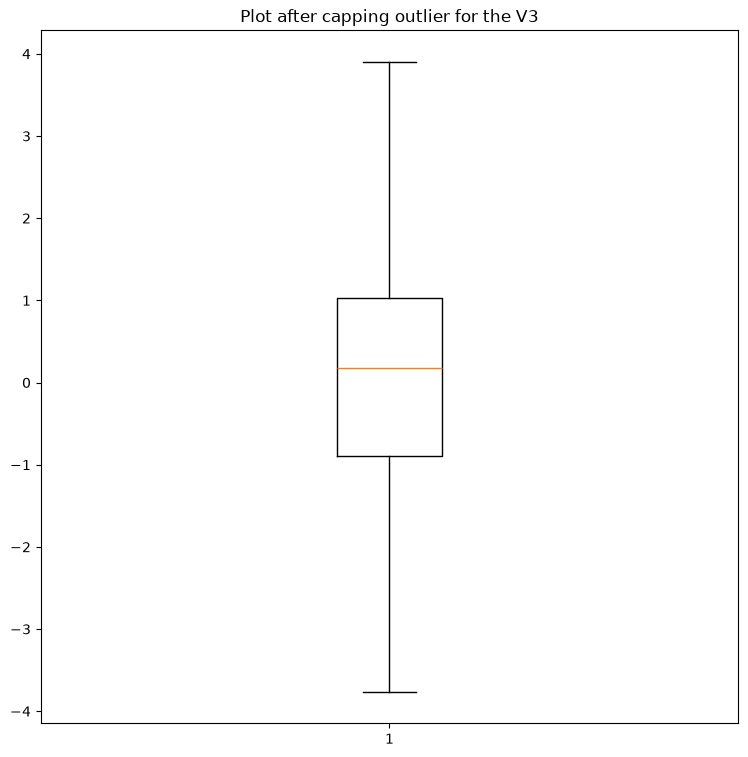

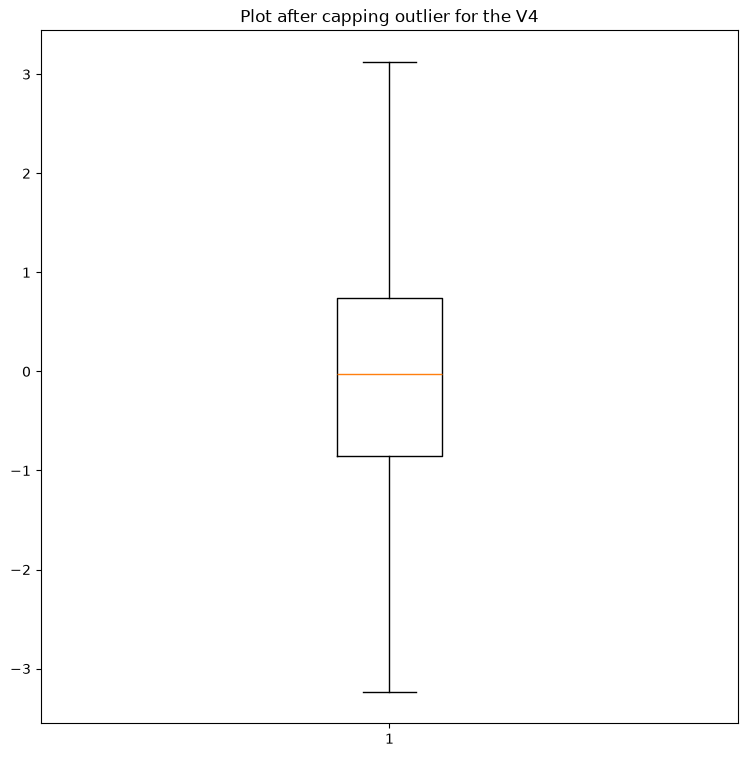

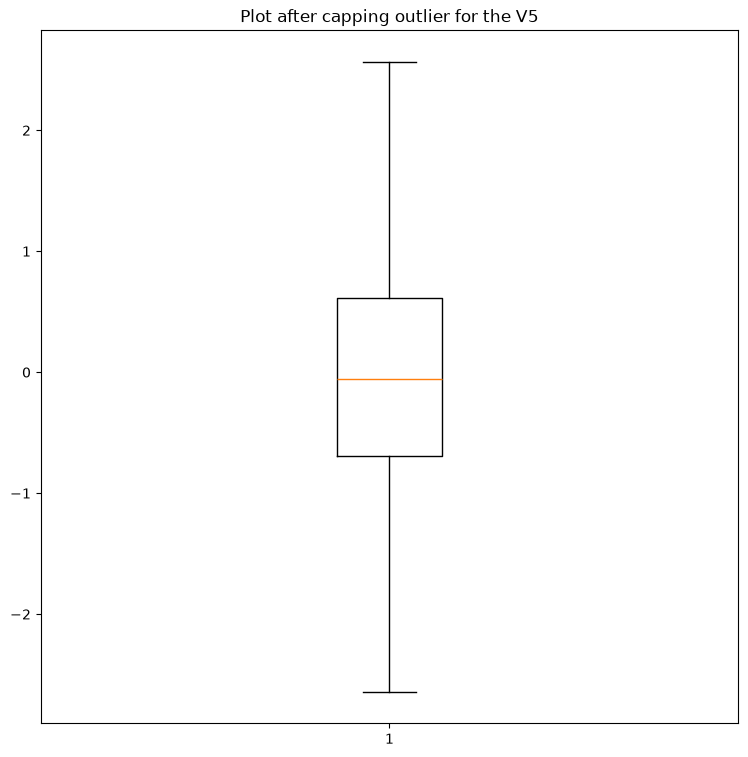

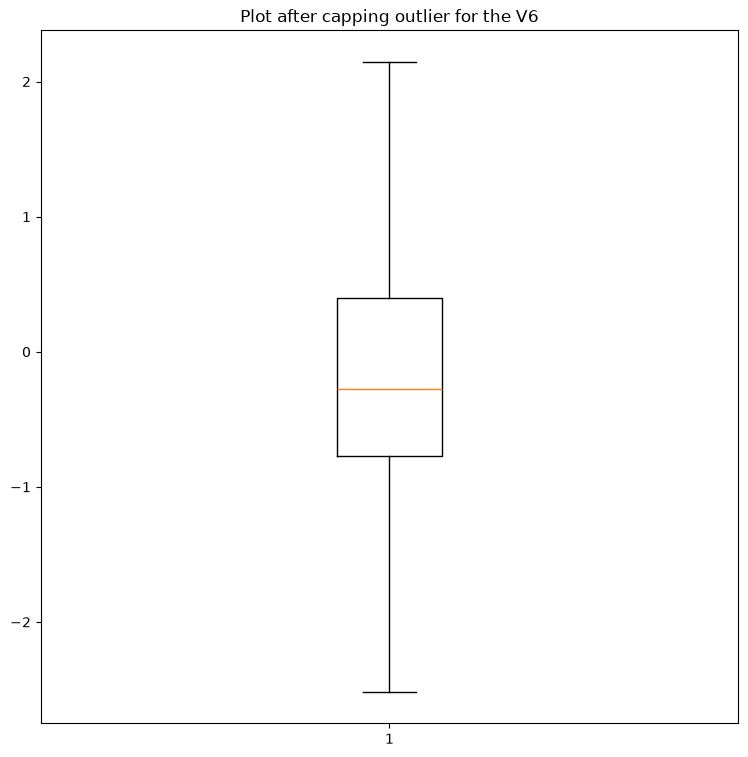

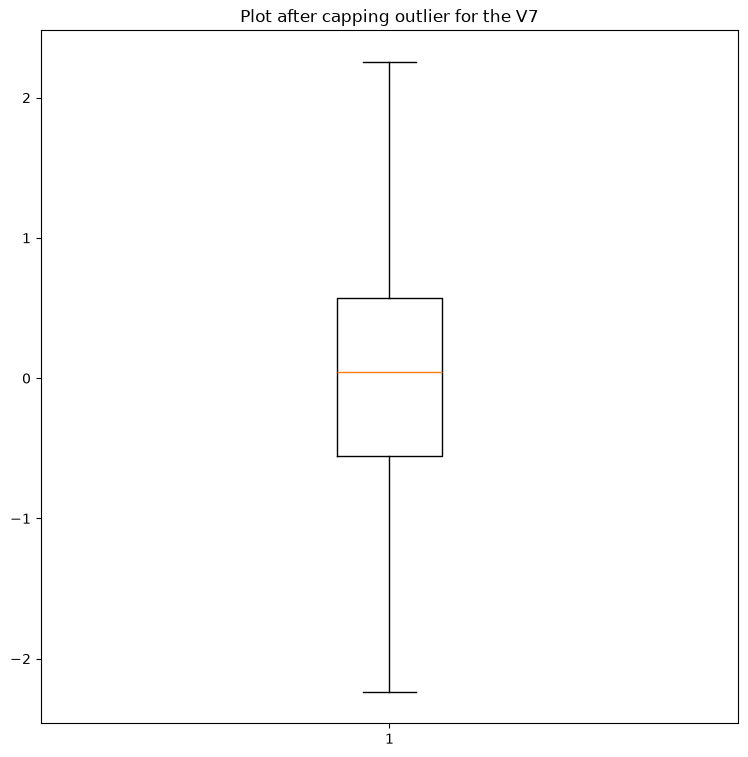

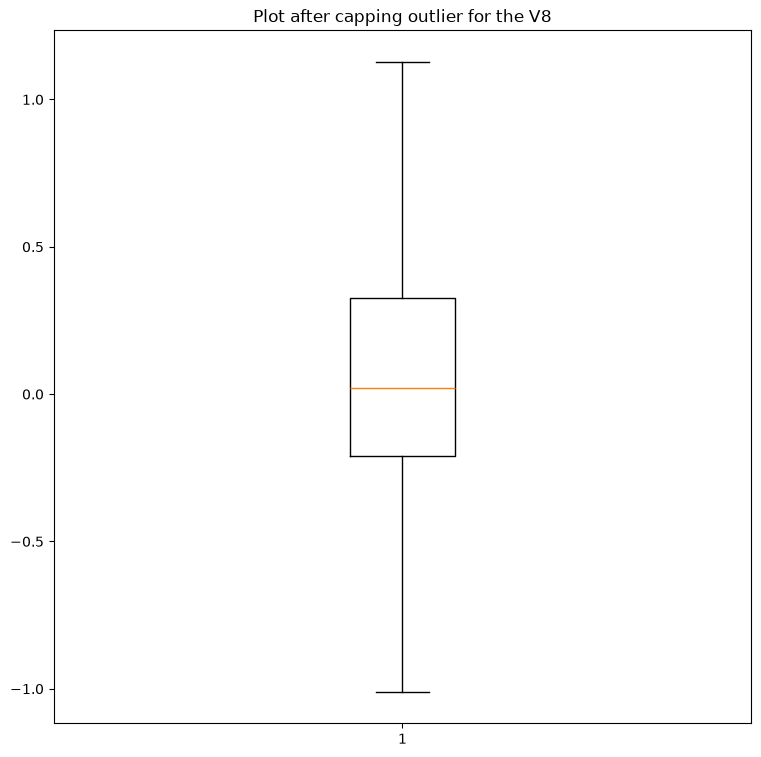

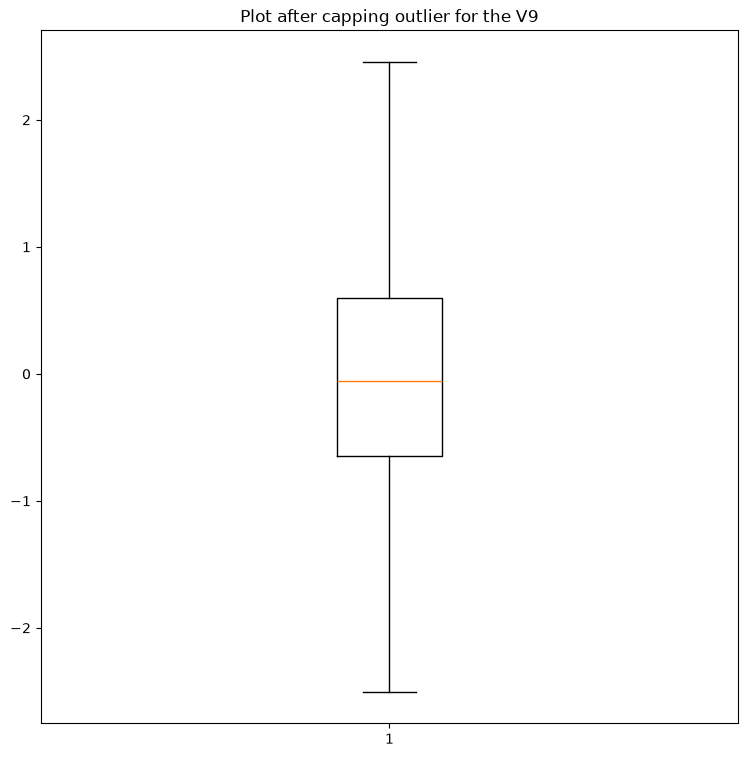

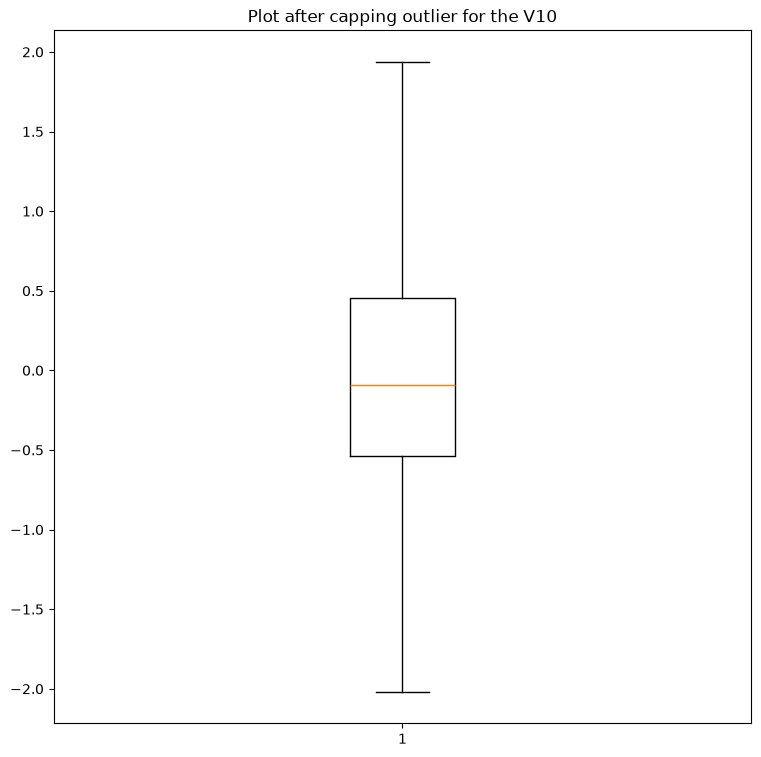

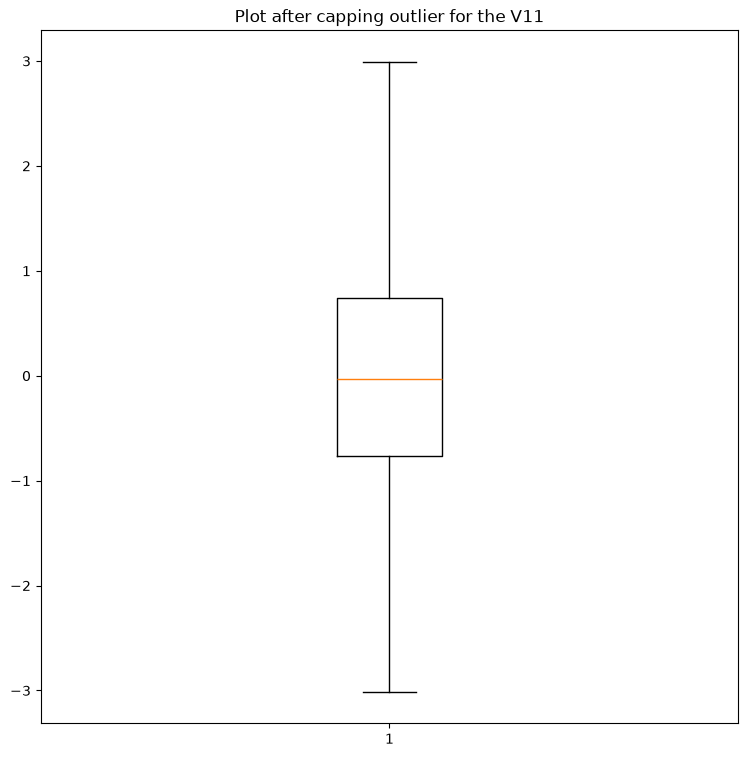

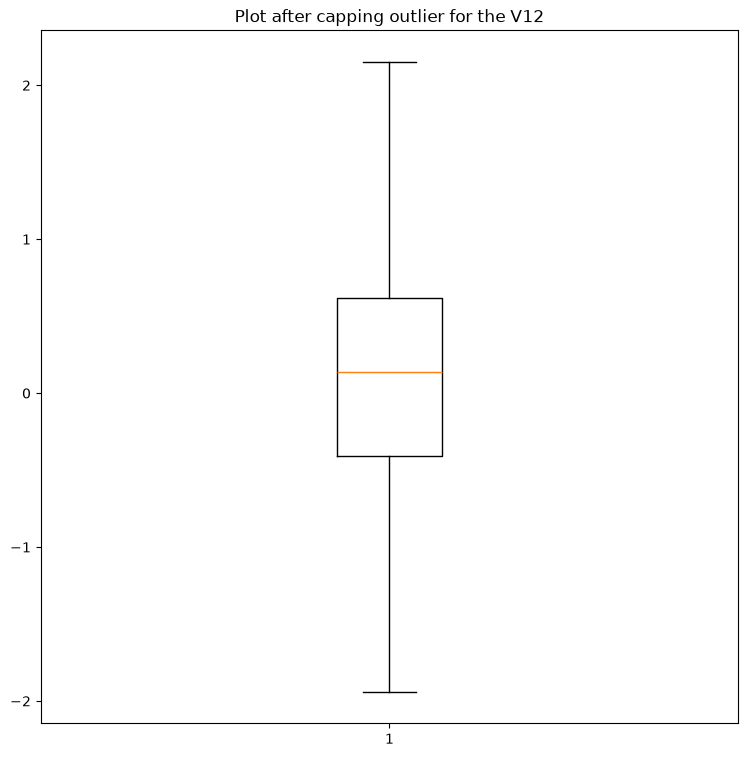

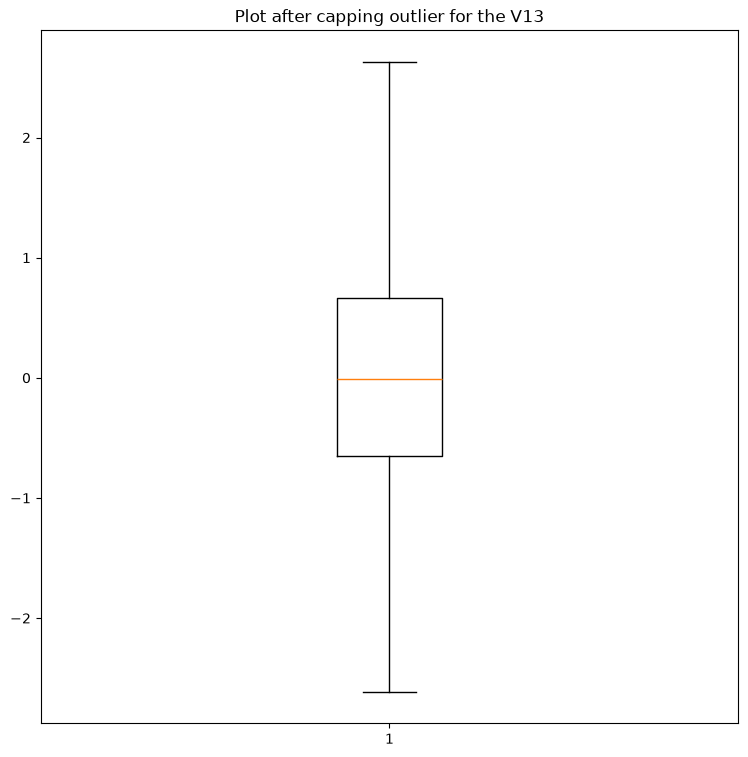

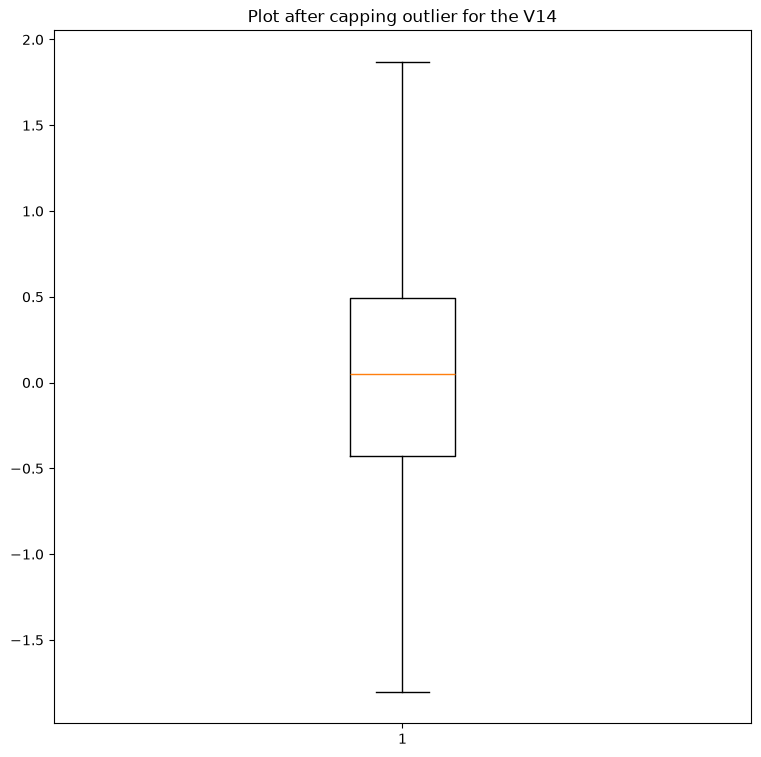

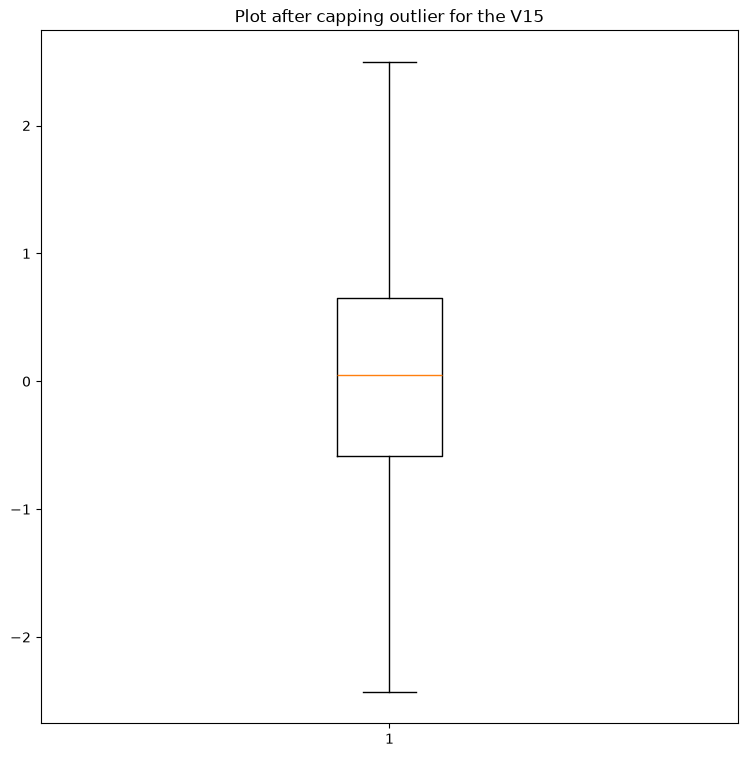

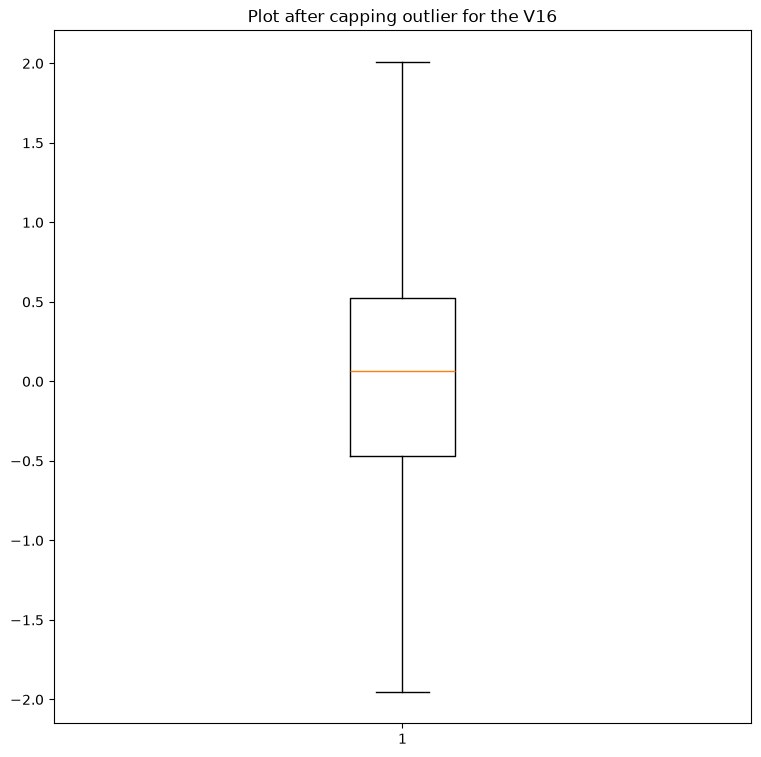

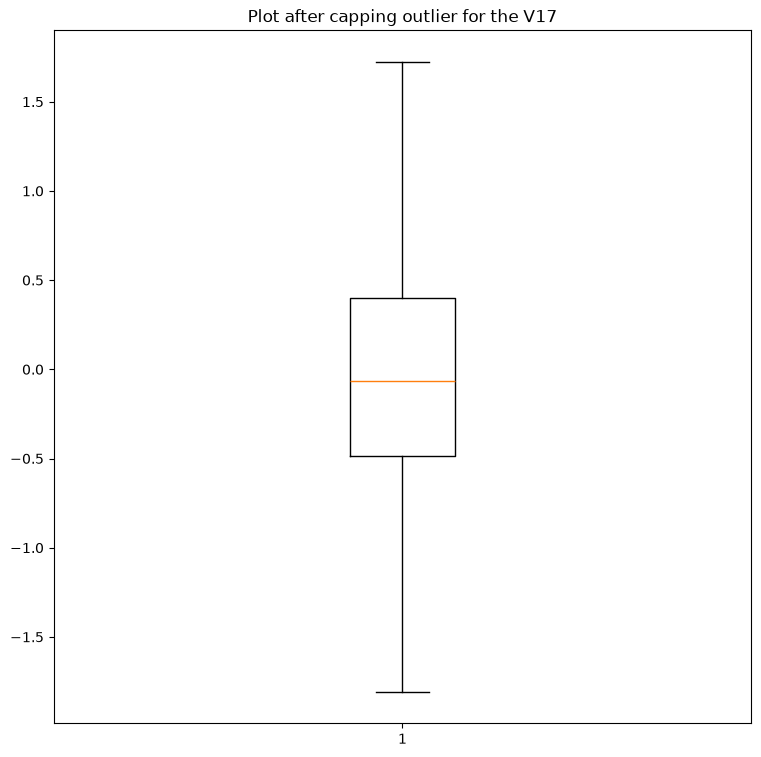

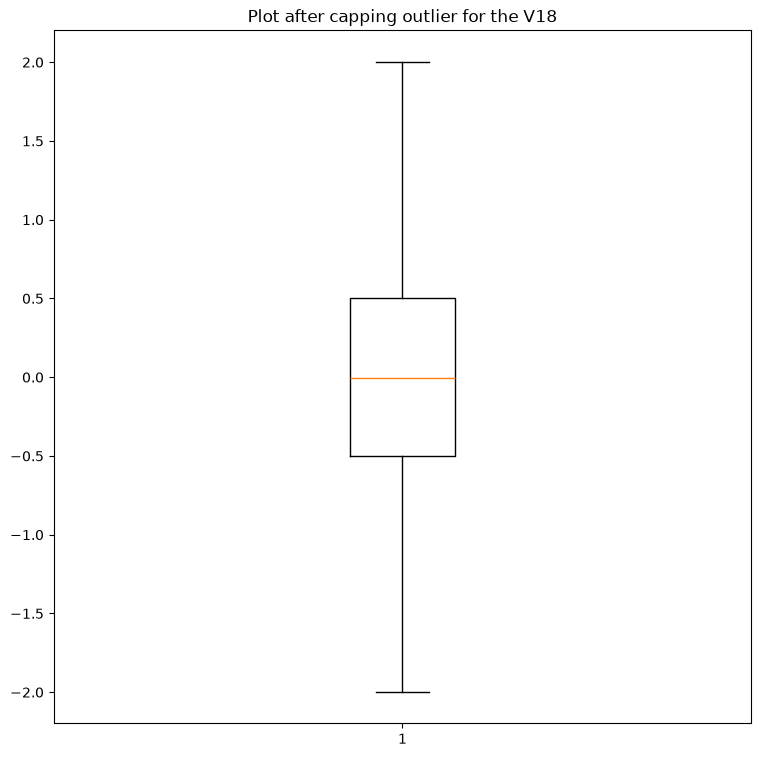

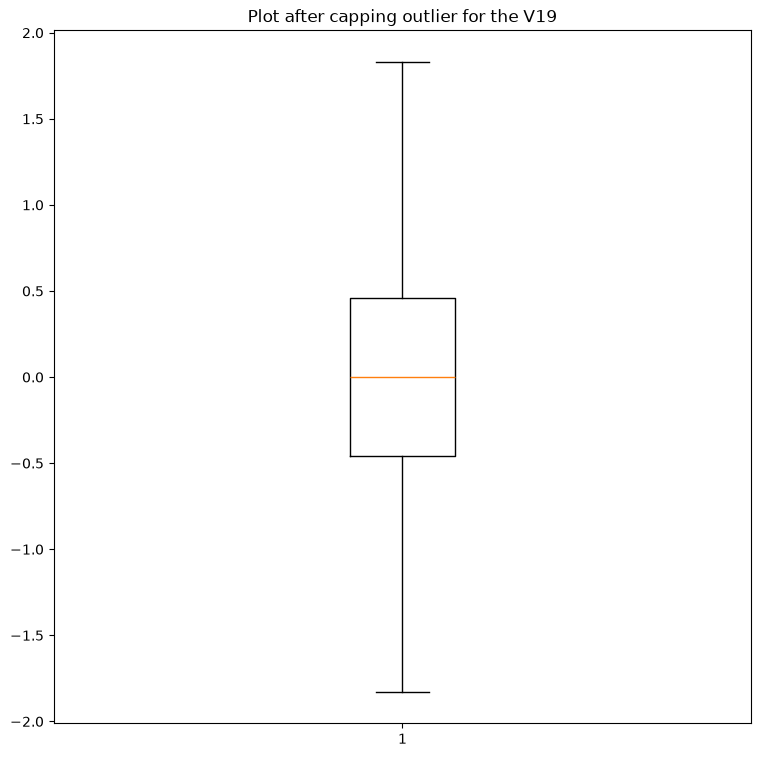

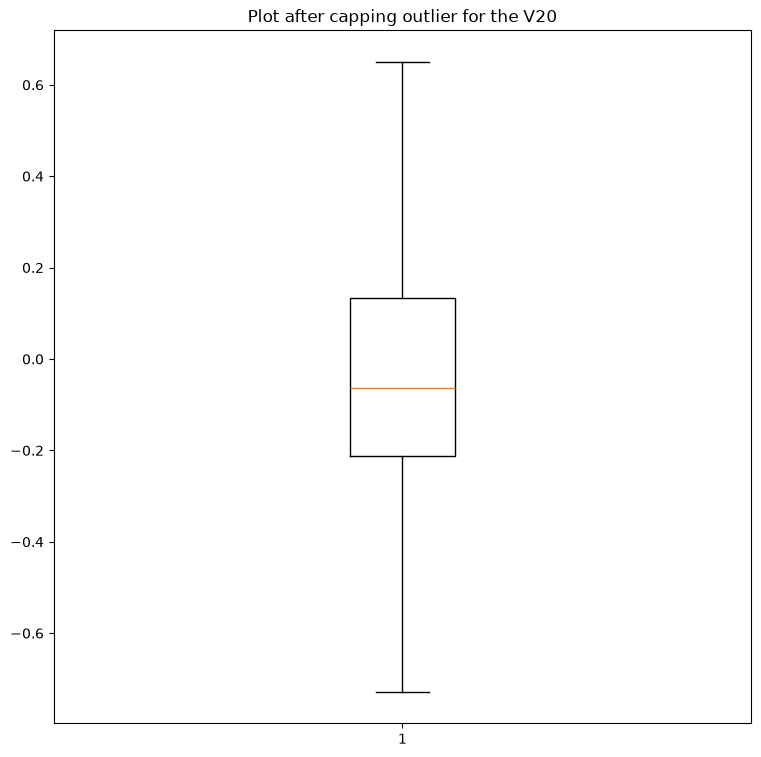

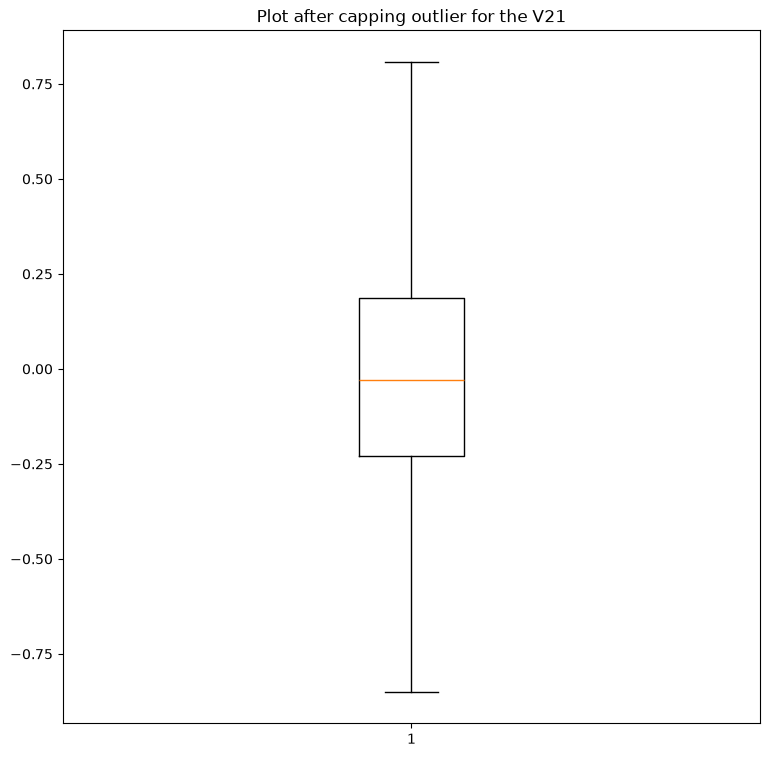

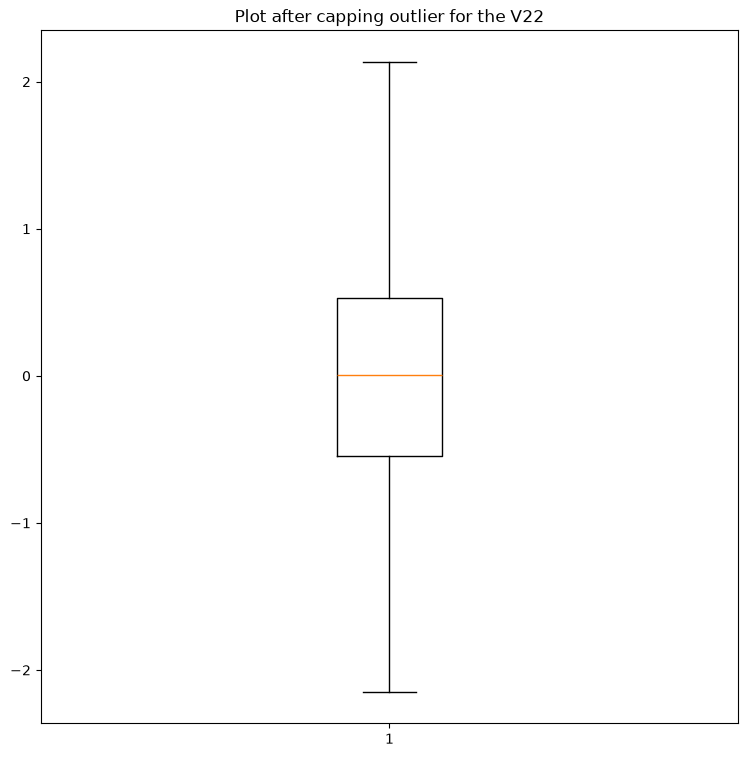

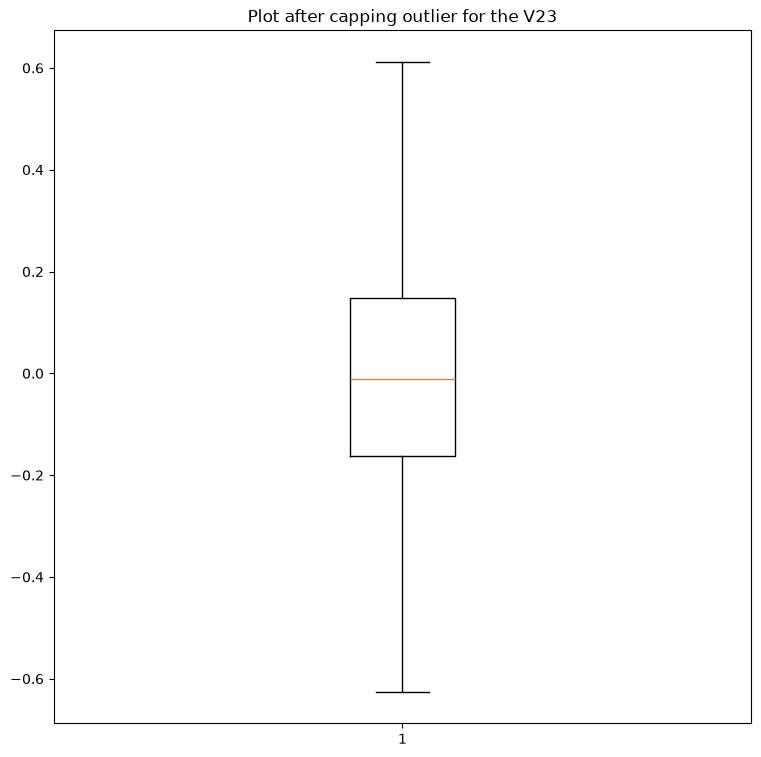

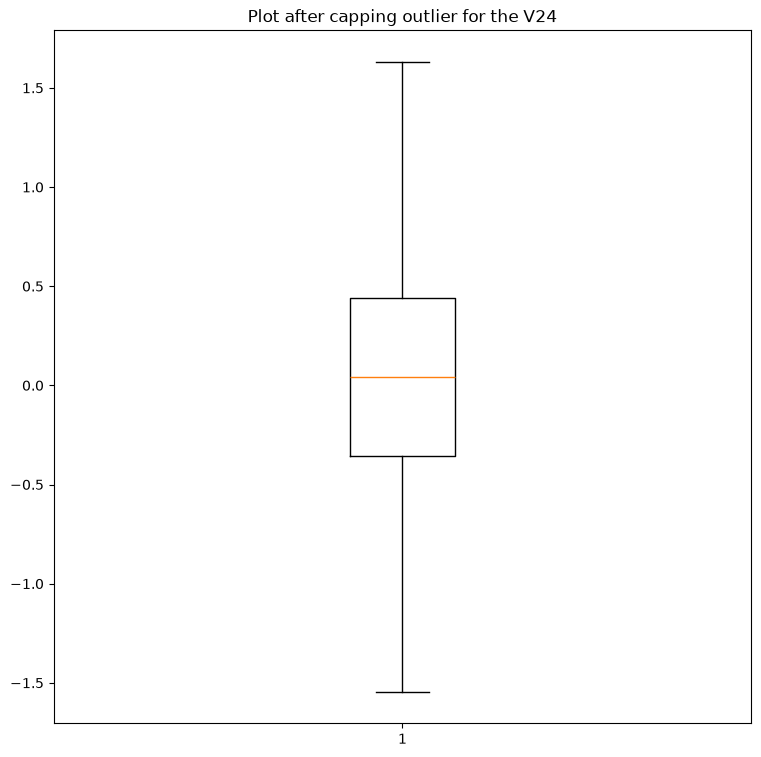

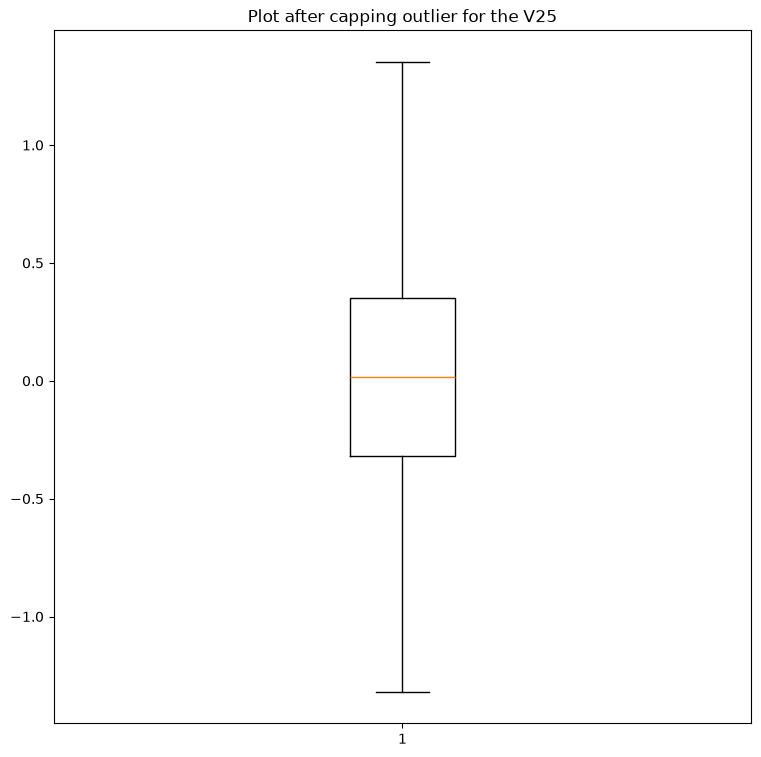

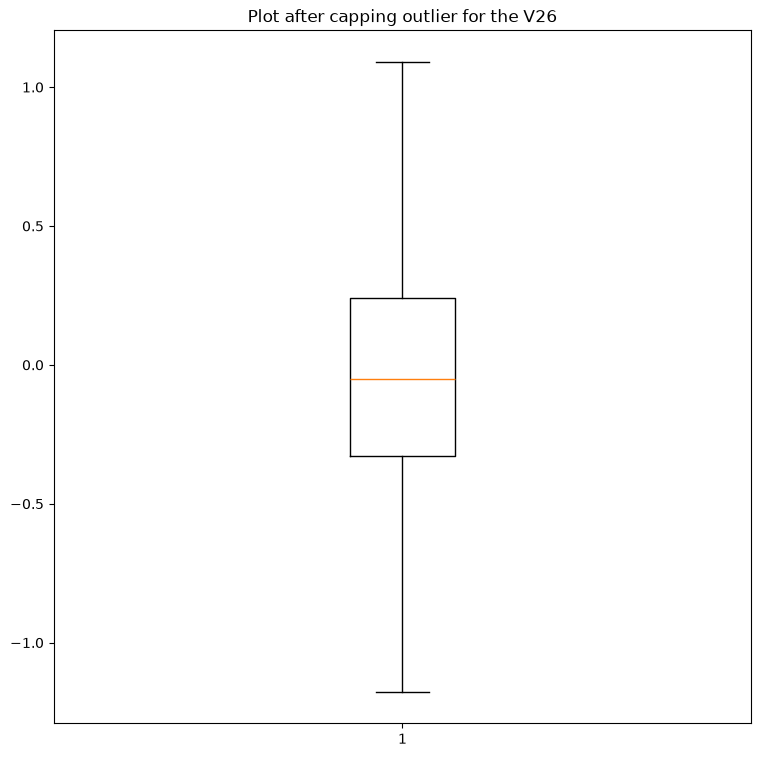

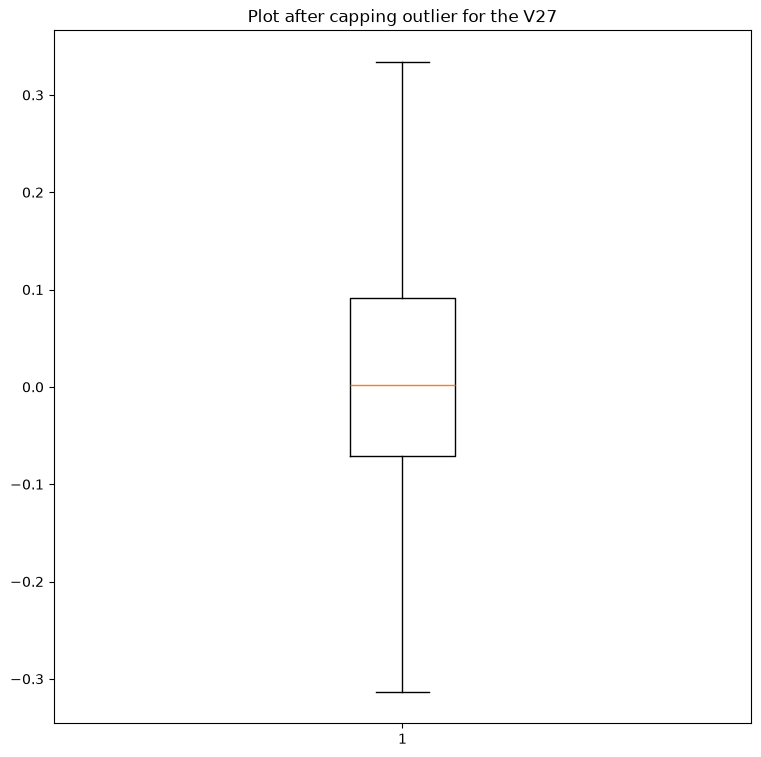

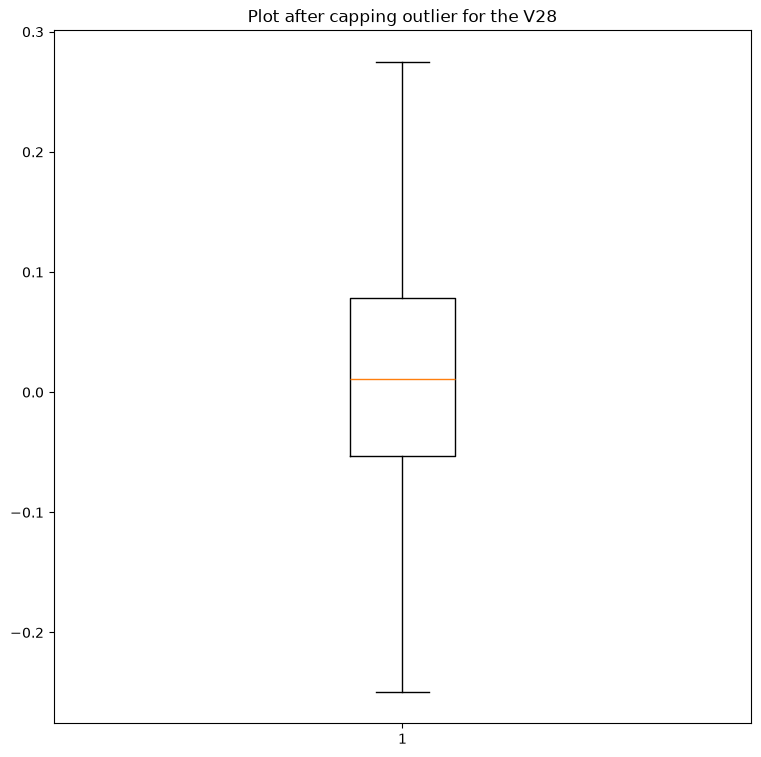

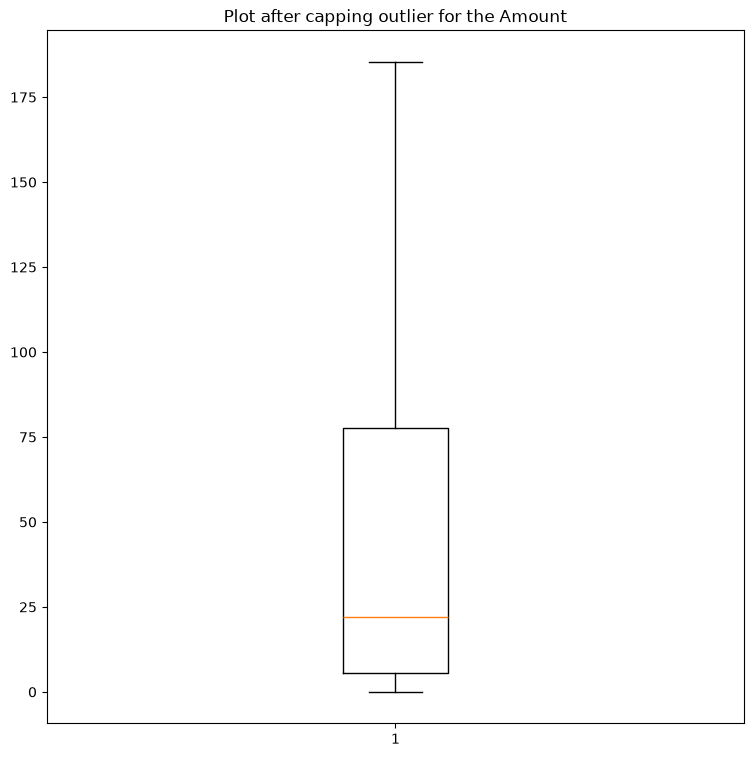

In [20]:
for col in df_trimmed.select_dtypes(include="float64"):
    plt.figure(figsize=(9,9))
    plt.boxplot(x=df_trimmed[col])
    plt.title(f"Plot after capping outlier for the {col}")
    plt.show()

Now the 2 datasets are ready namely *dfcopy* and *df_trimmed*. The next thing is to spot relations between the data

## 3. Correlation analysis

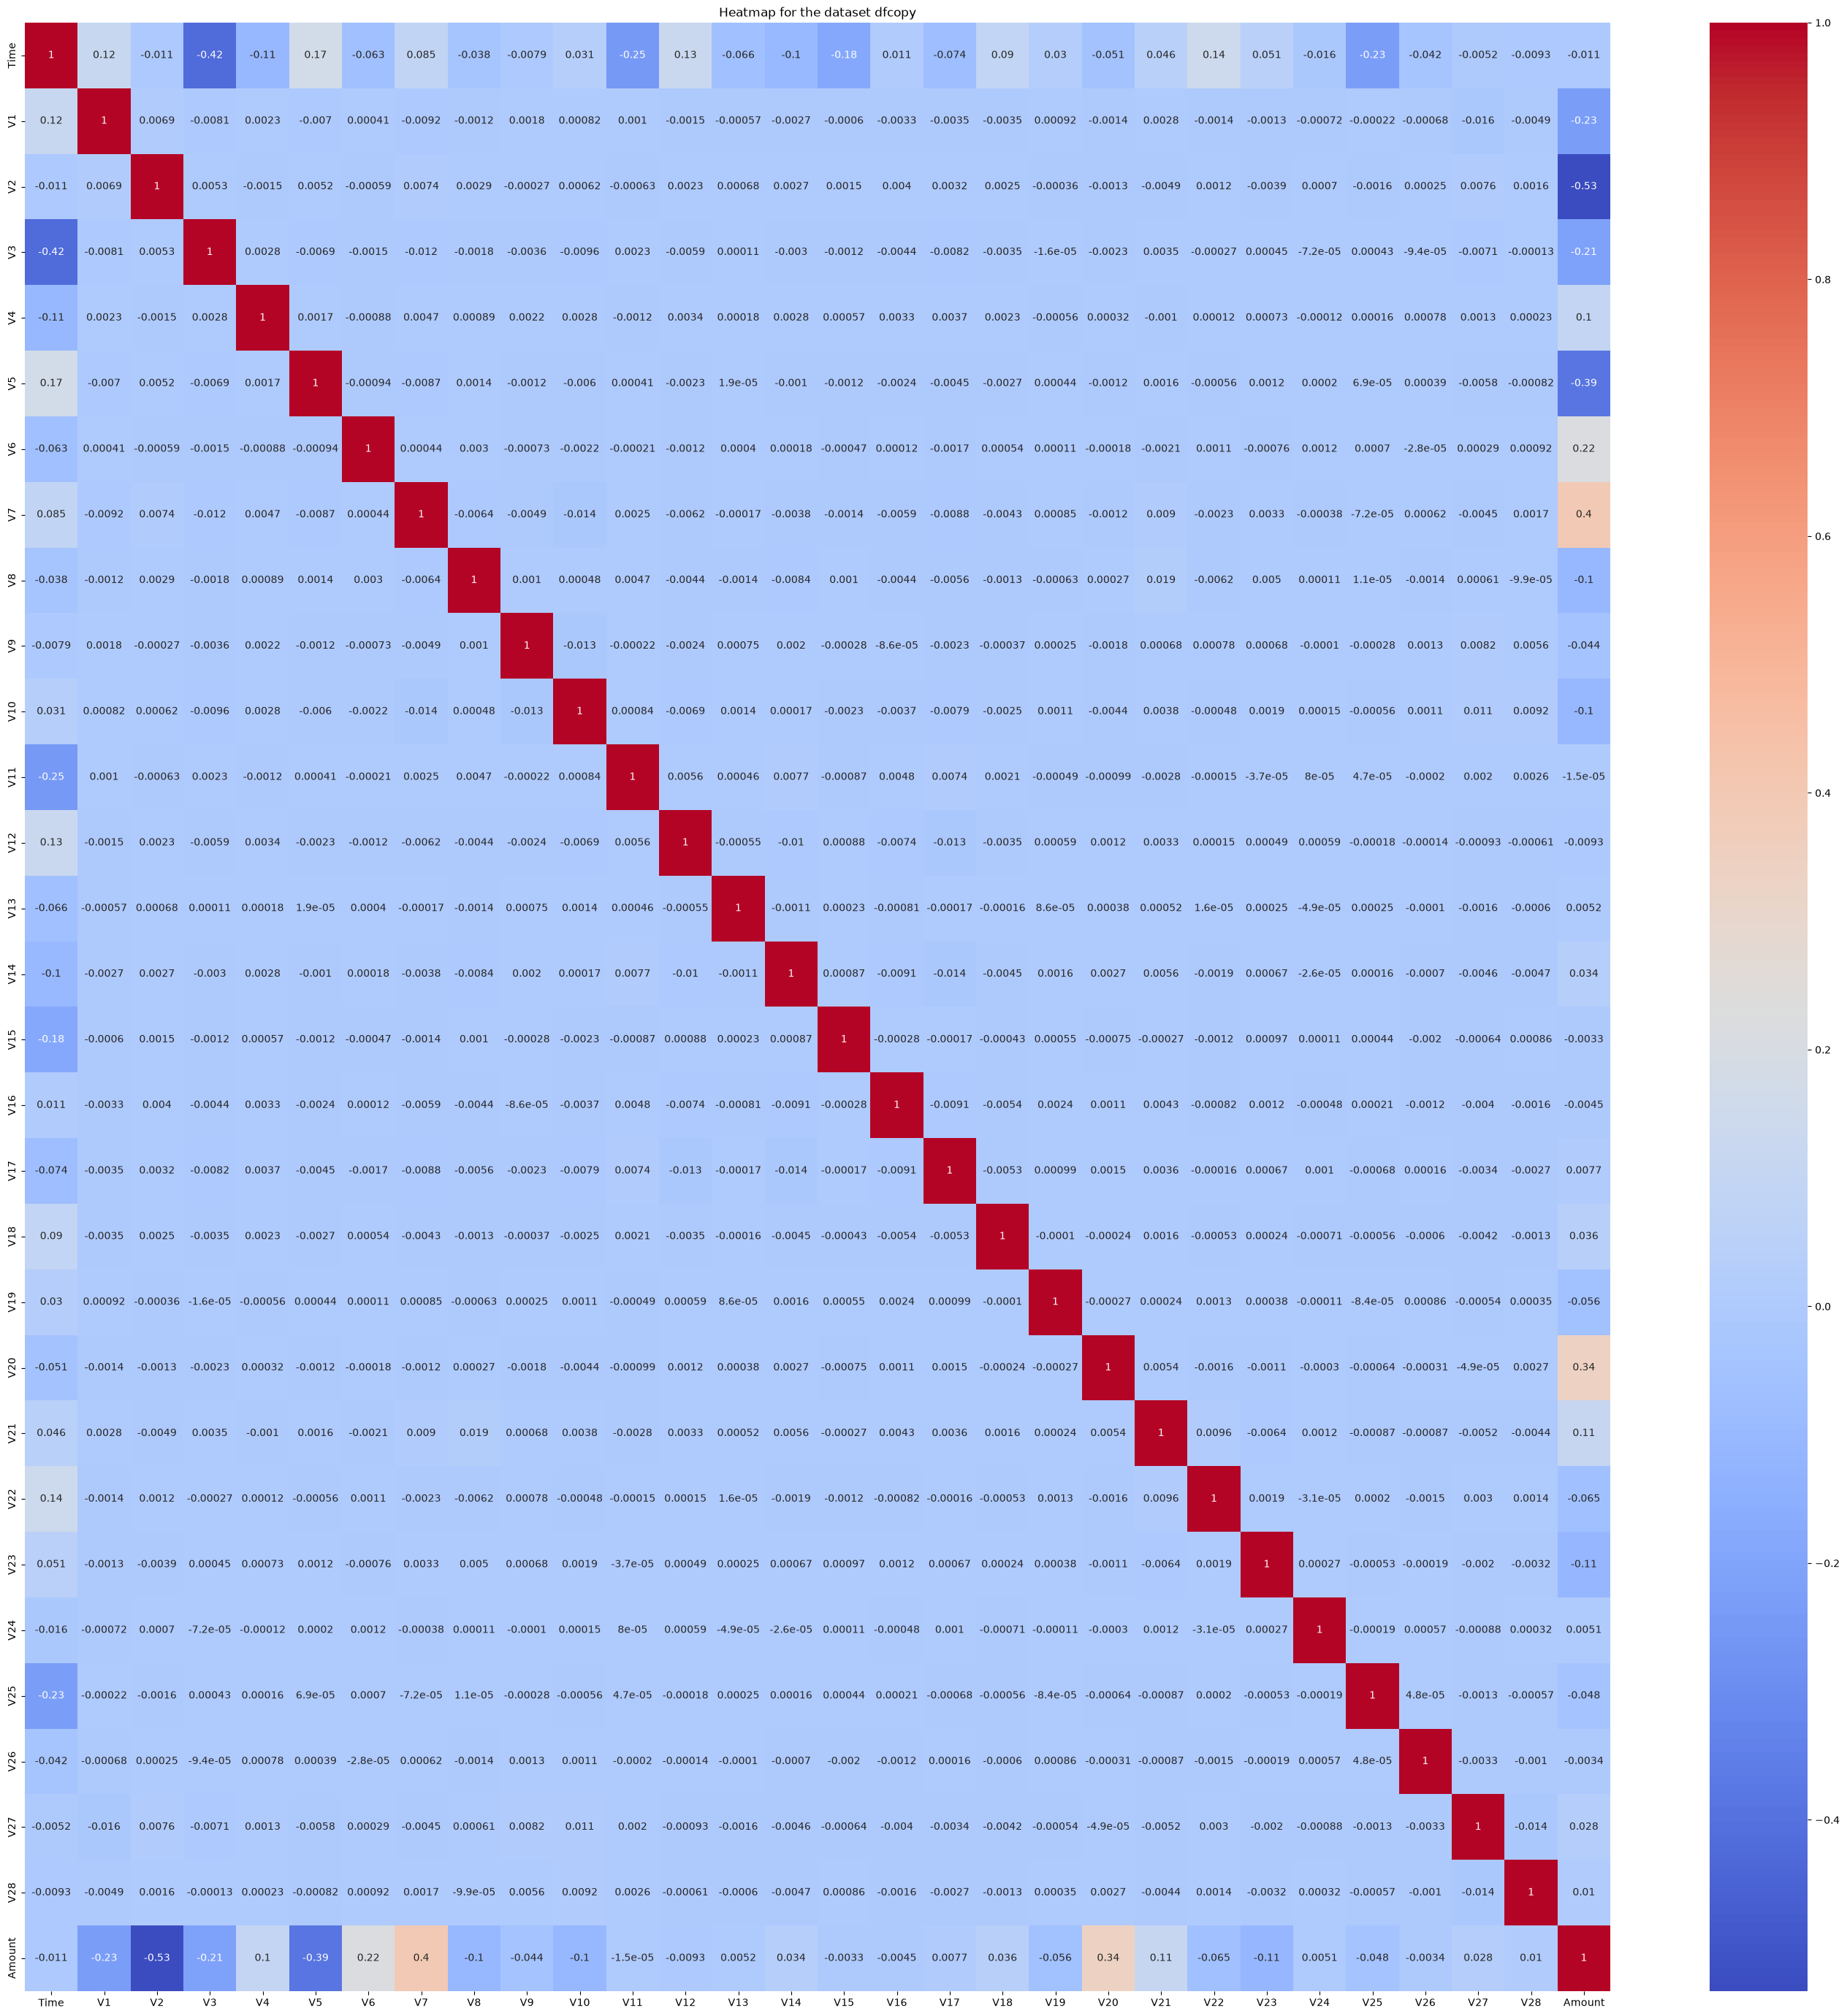

In [21]:
corr_copy = dfcopy.select_dtypes(include='float64').corr()
plt.figure(figsize=(35,35))
sns.heatmap(
    corr_copy,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for the dataset dfcopy")
plt.show()

There are no significant relations that can be observed form the heatmap indicating that the data might be synthetically generated. The only significant relations from the heatmap are as follows:
- Amount / v7 = 0.4
- Amount / v20 = 0.34
- Amount / v2 = -0.53
- v3 / time = -0.42

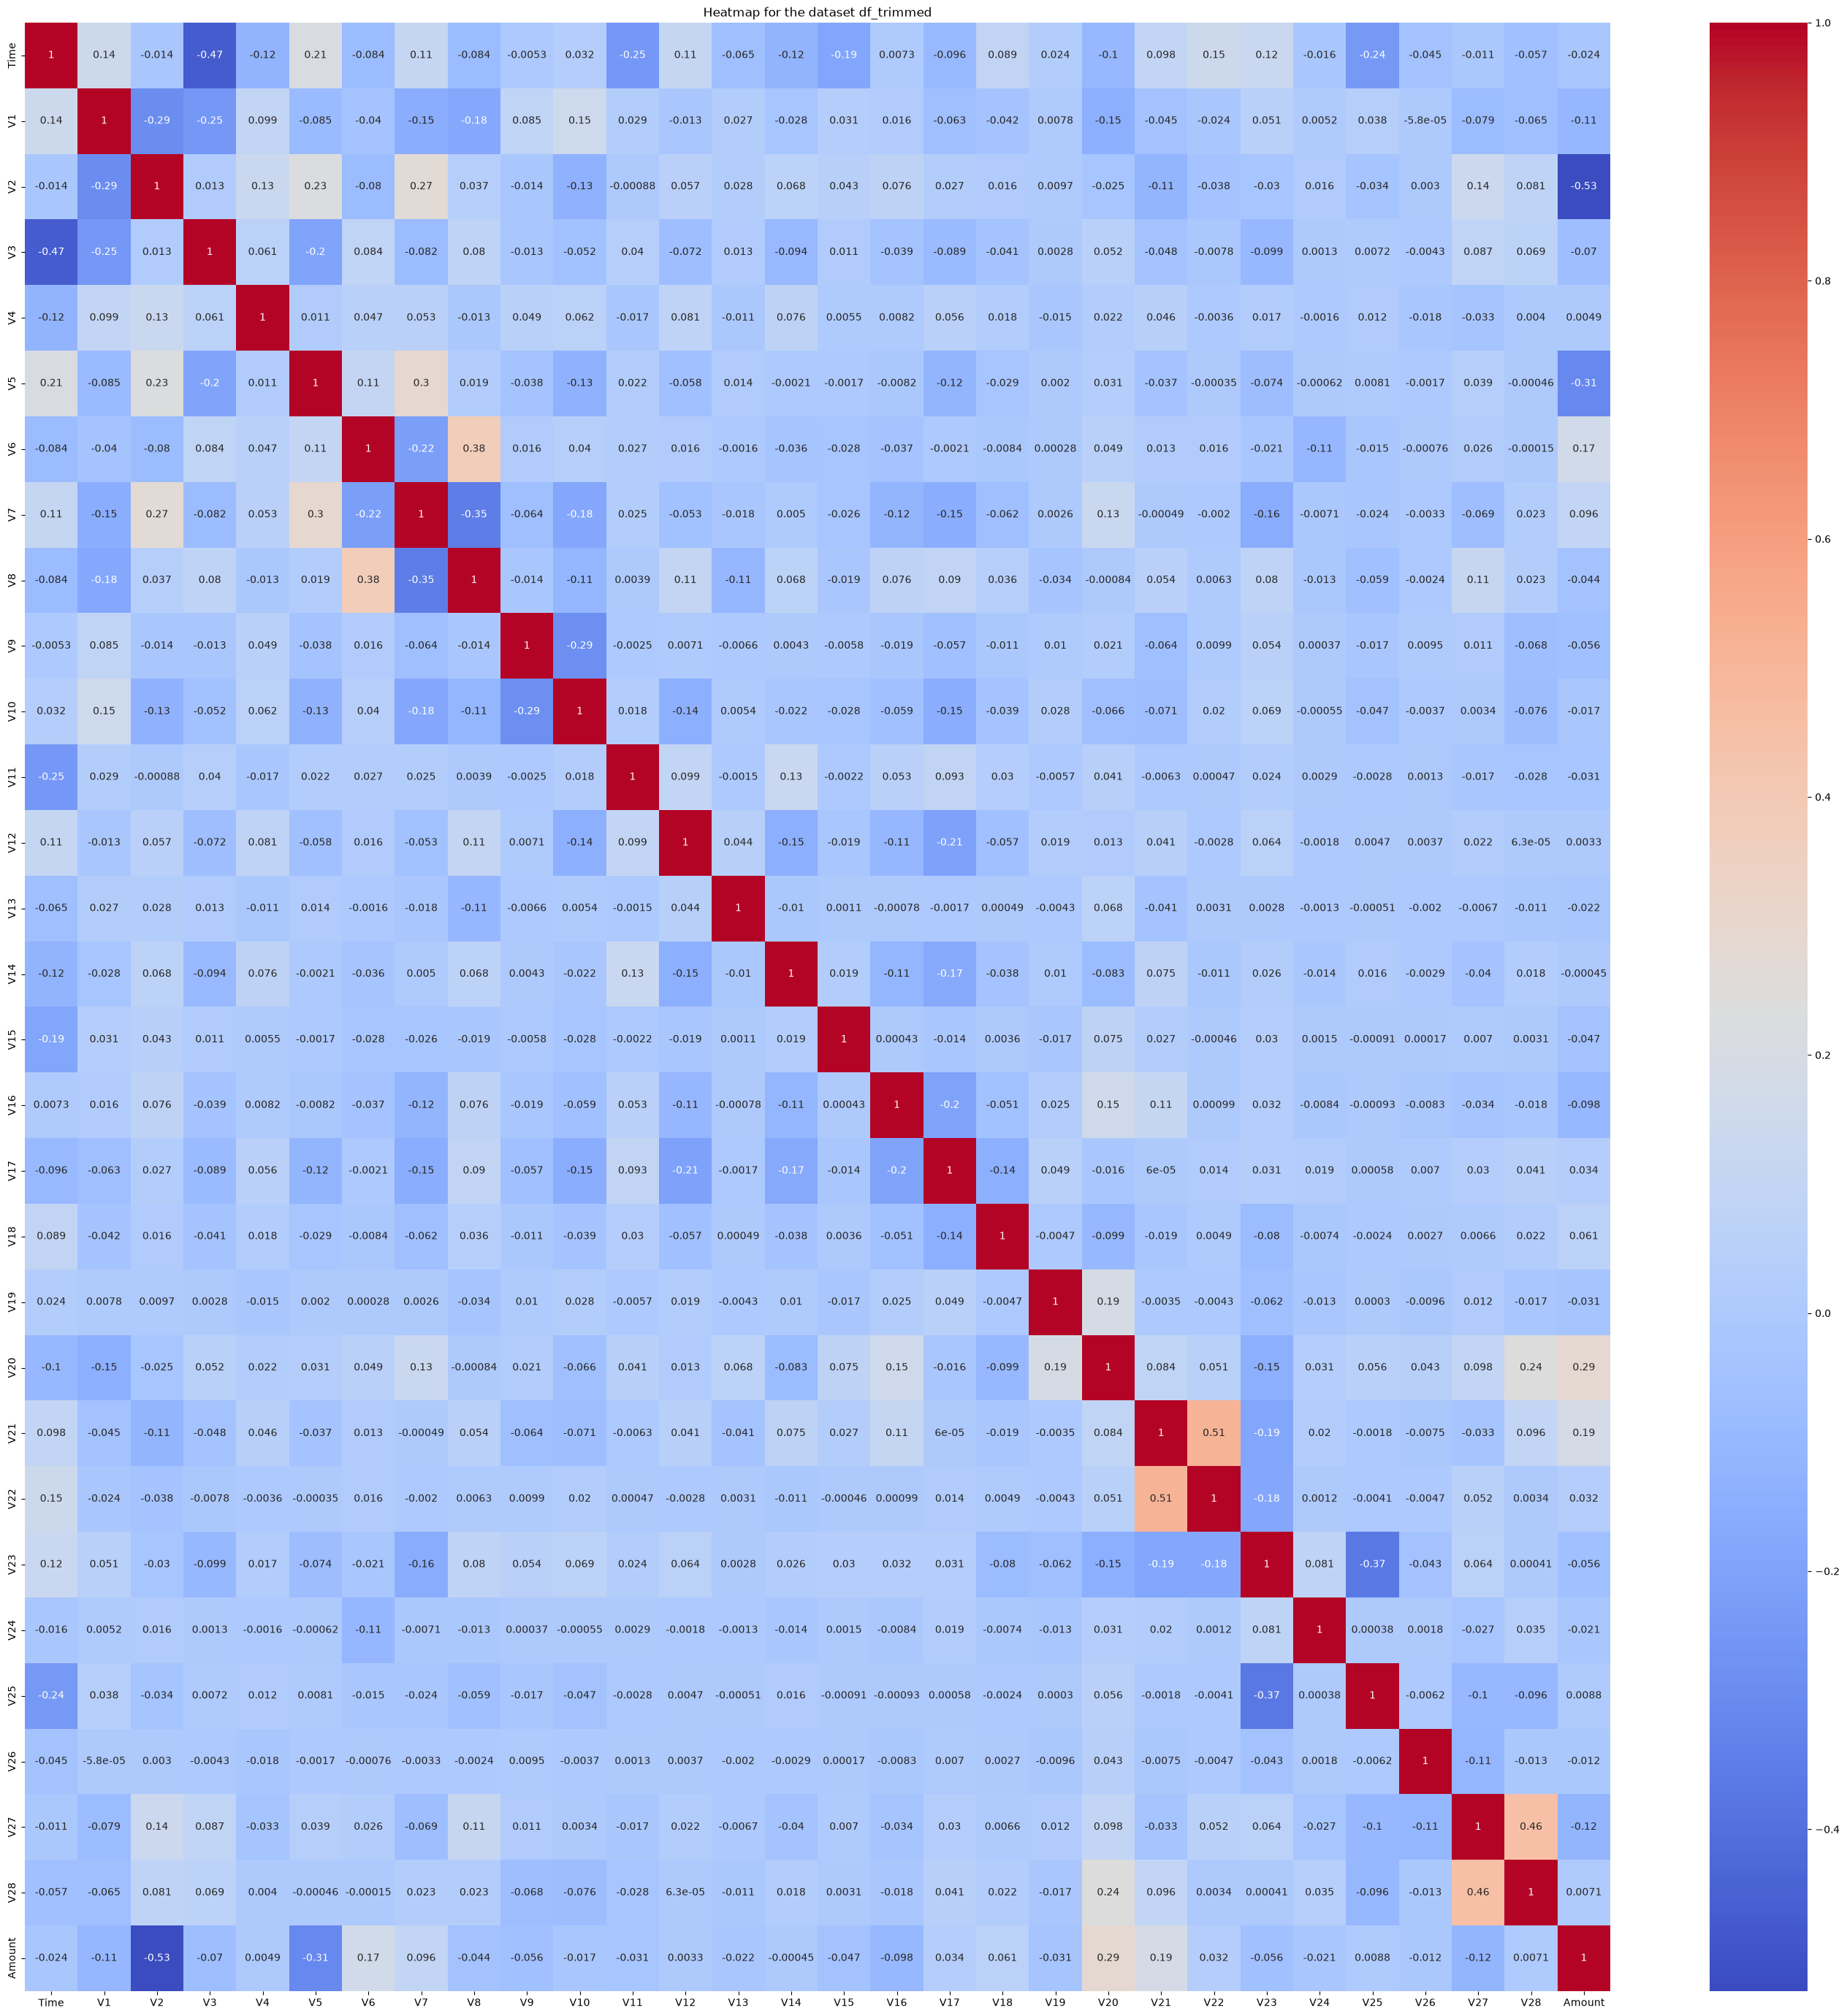

In [22]:
corr_trim = df_trimmed.select_dtypes(include='float64').corr()
plt.figure(figsize=(35,35))
sns.heatmap(
    corr_trim,
    annot=True,
    cmap="coolwarm"
)
plt.title("Heatmap for the dataset df_trimmed")
plt.show()

Not much significant relationships in this as well but due to the capping the heatmap has become a bit stronger. Some relations are as follows:
- Amount / V2 = -0.53
- V3 / Time = -0.47
- v28 / v27 = 0.46
- v22 / v21 = 0.51

## 4. Preparing the data for the logistic regression copy model training

For the dataframe dfcopy

In [23]:
X_copy = dfcopy.drop("Class", axis=1)
y_copy = dfcopy["Class"]

In [24]:
X_copy_train, X_copy_test, y_copy_train, y_copy_test = train_test_split(X_copy, y_copy, test_size=0.2, random_state=42)

print(X_copy_train.shape)
print(X_copy_test.shape)
print(y_copy_train.shape)
print(y_copy_test.shape)

logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced")

logistic_model.fit(X_copy_train, y_copy_train)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

Accuracy score:  0.9765269798752335
Confusion Matrix: 
 [[55333  1323]
 [    9    81]]
classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.90      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.94      0.55     56746
weighted avg       1.00      0.98      0.99     56746

ROC AUC score:  0.9728814639618438


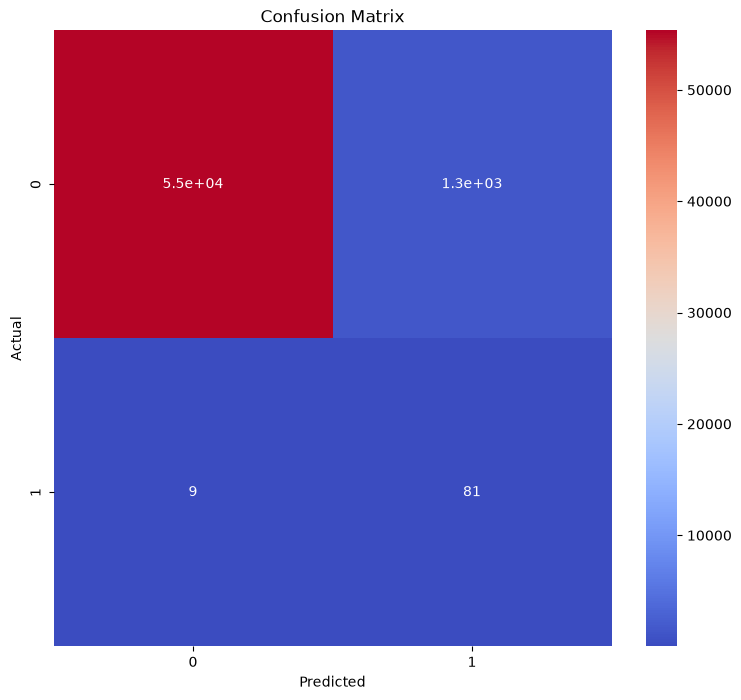

In [25]:
y_copy_pred = logistic_model.predict(X_copy_test)
y_copy_probab = logistic_model.predict_proba(X_copy_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_copy_test, y_copy_pred))

cm_copy = confusion_matrix(y_copy_test, y_copy_pred)
print("Confusion Matrix: \n", cm_copy)

print("classification Report: \n", classification_report(y_copy_test, y_copy_pred))

roc_auc_copy = roc_auc_score(y_copy_test, y_copy_probab)
print("ROC AUC score: ", roc_auc_copy)

plt.figure(figsize=(9,8))
sns.heatmap(cm_copy, annot=True, cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
dfcopy.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0


In [27]:
# 1. Define the columns exactly as your model expects them (excluding 'Class')
features = (
    ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
)

# 2. Generate sample data (e.g., 3 rows of dummy data)
np.random.seed(42)
num_samples = 1

demo_data = {
    "Time": np.random.uniform(0, 100000, num_samples),
    **{
        f"V{i}": np.random.normal(0, 1, num_samples) for i in range(1, 29)
    },
    "Amount": np.random.uniform(1, 500, num_samples),
}

# 3. Create the demo DataFrame
df_copy_demo = pd.DataFrame(demo_data, columns=features)


# Display the generated demo dataframe
print("Demo DataFrame for Model Input: ")
print(df_copy_demo)

# --- test your model ---
predictions_copy = logistic_model.predict(df_copy_demo)
probabilities_copy = logistic_model.predict_proba(df_copy_demo)

print("Prediction: ", predictions_copy)
print("Probabilities: ", probabilities_copy)

Demo DataFrame for Model Input: 
           Time       V1        V2        V3        V4        V5       V6  \
0  37454.011885 -1.11188  0.318902  0.279041  1.010515 -0.580878 -0.52517   

        V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.57138 -0.924083 -2.612549  ...  0.394233  0.122219 -0.515436 -0.600254   

       V24       V25      V26       V27       V28      Amount  
0  0.94744  0.291034 -0.63556 -1.021552 -0.161755  248.093278  

[1 rows x 30 columns]
Prediction:  [1]
Probabilities:  [[0.04839848 0.95160152]]


## 5. Preparing the data for the model with the trimmed dataset

In [28]:
X_trim = df_trimmed.drop("Class", axis=1)
y_trim = df_trimmed["Class"]

In [29]:
X_trim_train, X_trim_test, y_trim_train, y_trim_test = train_test_split(X_trim, y_trim, random_state=42, test_size=0.2)

trim_model = LogisticRegression(class_weight="balanced", max_iter=2000)

print(X_trim_train.shape)
print(X_trim_test.shape)
print(y_trim_train.shape)
print(y_trim_test.shape)


trim_model.fit(X_trim_train, y_trim_train)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


C:\Users\tusha\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

Accuracy score:  0.9706411024565608
Confusion Matrix: 
 [[54998  1658]
 [    8    82]]
classification Report: 
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56656
           1       0.05      0.91      0.09        90

    accuracy                           0.97     56746
   macro avg       0.52      0.94      0.54     56746
weighted avg       1.00      0.97      0.98     56746

ROC AUC score:  0.9748482067212652


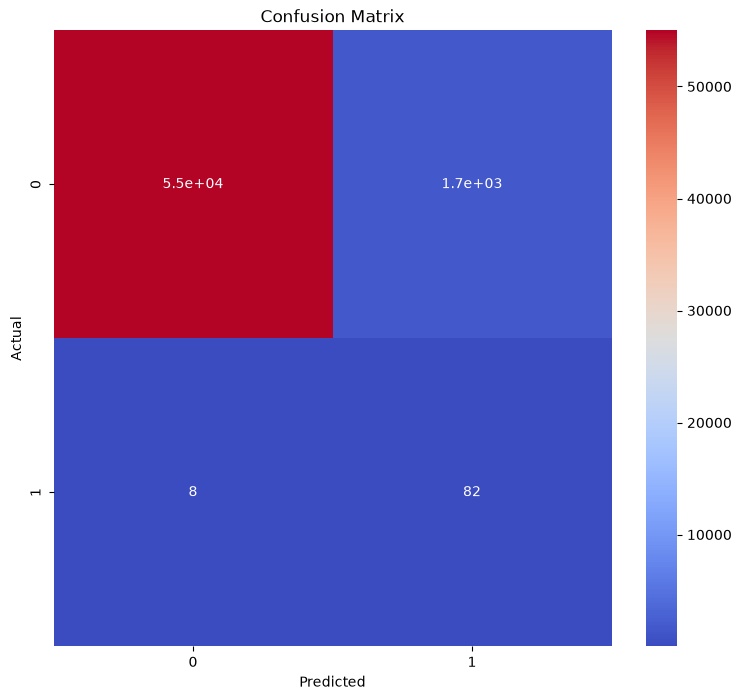

In [30]:
y_trim_pred = trim_model.predict(X_trim_test)
y_trim_probab = trim_model.predict_proba(X_trim_test)[:, 1]

print("Accuracy score: ", accuracy_score(y_trim_test, y_trim_pred))

cm_trim = confusion_matrix(y_trim_test, y_trim_pred)
print("Confusion Matrix: \n", cm_trim)

print("classification Report: \n", classification_report(y_copy_test, y_trim_pred))

roc_auc_trim = roc_auc_score(y_trim_test, y_trim_probab)
print("ROC AUC score: ", roc_auc_trim)

plt.figure(figsize=(9,8))
sns.heatmap(cm_trim, annot=True, cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
# 1. Define the columns exactly as your model expects them (excluding 'Class')
features_trim = (
    ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]
)

# 2. Generate sample data (e.g., 3 rows of dummy data)
np.random.seed(42)
num_samples_trim = 1

demo_data_trim = {
    "Time": np.random.uniform(0, 100000, num_samples_trim),
    **{
        f"V{i}": np.random.normal(0, 1, num_samples_trim) for i in range(1, 29)
    },
    "Amount": np.random.uniform(1, 500, num_samples_trim),
}

# 3. Create the demo DataFrame
df_trim_demo = pd.DataFrame(demo_data_trim, columns=features_trim)


# Display the generated demo dataframe
print("Demo DataFrame for Model Input: ")
print(df_trim_demo)

# --- test your model ---
predictions_trim = logistic_model.predict(df_trim_demo)
probabilities_trim = logistic_model.predict_proba(df_trim_demo)

print("Prediction: ", predictions_trim)
print("Probabilities: ", probabilities_trim)

Demo DataFrame for Model Input: 
           Time       V1        V2        V3        V4        V5       V6  \
0  37454.011885 -1.11188  0.318902  0.279041  1.010515 -0.580878 -0.52517   

        V7        V8        V9  ...       V20       V21       V22       V23  \
0 -0.57138 -0.924083 -2.612549  ...  0.394233  0.122219 -0.515436 -0.600254   

       V24       V25      V26       V27       V28      Amount  
0  0.94744  0.291034 -0.63556 -1.021552 -0.161755  248.093278  

[1 rows x 30 columns]
Prediction:  [1]
Probabilities:  [[0.04839848 0.95160152]]


In [32]:
# testing the model after class weight balance with a not fraud dataframe

# Define the 30 features exactly as your model expects them
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Normal transaction data based right on your dataset's medians
normal_data = {
    "Time": [84692.5],  # 50% (Median) Time
    "Amount": [22.0],  # 50% (Median) Amount
}

# Fill V1 through V28 with values close to their medians (roughly 0)
for i in range(1, 29):
    normal_data[f"V{i}"] = [0.01]

# Create the normal demo DataFrame
df_normal_demo = pd.DataFrame(normal_data, columns=features)

# Display the full DataFrame
print("--- Normal Transaction Demo DataFrame --- \n")
print(df_normal_demo)

predictions = logistic_model.predict(df_normal_demo)
probabilities = logistic_model.predict_proba(df_normal_demo)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

--- Normal Transaction Demo DataFrame --- 

      Time    V1    V2    V3    V4    V5    V6    V7    V8    V9  ...   V20  \
0  84692.5  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  ...  0.01   

    V21   V22   V23   V24   V25   V26   V27   V28  Amount  
0  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01    22.0  

[1 rows x 30 columns]
Prediction:  [0]
Probabilities:  [[0.96460092 0.03539908]]


In [33]:
# testing the model after class weight balance with a not fraud dataframe

# Define the 30 features exactly as your model expects them
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Fraud transaction data based on extreme outlier values from your summary
fraud_data = {
    "Time": [150000.0],  # High transaction time
    "Amount": [999.0],  # Well above the 75th percentile (77.51)
}

# Fill V1 through V28 with extreme values near the dataset's mins and maxes
# Alternating signs to create a highly anomalous multi-variable profile
for i in range(1, 29):
    if i % 2 == 0:
        fraud_data[f"V{i}"] = [
            5.5
        ]  # Pushing significantly past the 75% marks
    else:
        fraud_data[f"V{i}"] = [
            -8.5
        ]  # Dropping deep into the negative minimum spaces

# Create the fraud demo DataFrame
df_fraud_demo = pd.DataFrame(fraud_data, columns=features)

# Display the full DataFrame
print("--- Fraud Transaction Demo DataFrame ---")
print(df_fraud_demo)

predictions = logistic_model.predict(df_fraud_demo)
probabilities = logistic_model.predict_proba(df_fraud_demo)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

--- Fraud Transaction Demo DataFrame ---
       Time   V1   V2   V3   V4   V5   V6   V7   V8   V9  ...  V20  V21  V22  \
0  150000.0 -8.5  5.5 -8.5  5.5 -8.5  5.5 -8.5  5.5 -8.5  ...  5.5 -8.5  5.5   

   V23  V24  V25  V26  V27  V28  Amount  
0 -8.5  5.5 -8.5  5.5 -8.5  5.5   999.0  

[1 rows x 30 columns]
Prediction:  [0]
Probabilities:  [[9.99966512e-01 3.34881130e-05]]


In [34]:
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# A data point tailored to match the true signature of actual fraud cases
true_fraud_signature = {
    "Time": [80000.0],
    "Amount": [99.0],
}

# Real credit card fraud heavily drives specific components into negative or positive directions
for i in range(1, 29):
    if i in [4, 11, 2]:  # These V-features usually go highly positive in fraud
        true_fraud_signature[f"V{i}"] = [4.5]
    elif i in [14, 17, 12, 10, 7]:  # These go drastically negative in fraud
        true_fraud_signature[f"V{i}"] = [-6.0]
    else:
        true_fraud_signature[f"V{i}"] = [
            0.0
        ]  # Leave the rest neutral to isolate the effect

df_true_fraud = pd.DataFrame(true_fraud_signature, columns=features)

# --- Test this new point ---
predictions = logistic_model.predict(df_true_fraud)
probabilities = logistic_model.predict_proba(df_true_fraud)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

Prediction:  [1]
Probabilities:  [[5.32190736e-10 9.99999999e-01]]


In [35]:
#subtle fraud
features = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount"]

# Dialing back the intensity to catch the imbalanced model off guard
subtle_fraud_signature = {
    "Time": [80000.0],
    "Amount": [45.0],  # A more modest, regular-looking amount
}

# We lower the magnitudes so it looks borderline normal
for i in range(1, 29):
    if i in [4, 11, 2]:
        subtle_fraud_signature[f"V{i}"] = [
            1.8
        ]  # Noticeable, but not extreme positive shift
    elif i in [14, 17, 12, 10, 7]:
        subtle_fraud_signature[f"V{i}"] = [
            -2.2
        ]  # Noticeable, but not extreme negative shift
    else:
        subtle_fraud_signature[f"V{i}"] = [0.0]

df_subtle_fraud = pd.DataFrame(subtle_fraud_signature, columns=features)

# --- Test this new point ---
predictions = logistic_model.predict(df_subtle_fraud)
probabilities = logistic_model.predict_proba(df_subtle_fraud)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

Prediction:  [1]
Probabilities:  [[0.00263916 0.99736084]]


In [36]:
y_pred = logistic_model.predict(X_copy_test)
print(classification_report(y_copy_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.90      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.94      0.55     56746
weighted avg       1.00      0.98      0.99     56746



## 6. Preparing data for the copy dataset for decision tree model

In [37]:
# Since the assignment of the data and the train-test-split remains the same so the same variable for 
# copy is used in decision tree here

decision_model = DecisionTreeClassifier(
    random_state=42,
    min_samples_leaf=10,
    min_samples_split=14,
    max_depth=9,
    class_weight="balanced"
)

decision_model.fit(X_copy_train, y_copy_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [38]:
pred_copy = decision_model.predict(X_copy_test) 

print("R2 score: ", r2_score(y_copy_test, pred_copy))
print("Mean absolute error: ", mean_absolute_error(y_copy_test, pred_copy))
print("Mean squared error: ", mean_squared_error(y_copy_test, pred_copy))
print("Root mean squared error: ", root_mean_squared_error(y_copy_test, pred_copy))

R2 score:  -5.855317079293357
Mean absolute error:  0.010855390688330455
Mean squared error:  0.010855390688330455
Root mean squared error:  0.10418920619877307


In [39]:
y_pred_dt = decision_model.predict(X_copy_test)

# 4. Evaluate using the CORRECT metrics
print("--- Decision Tree Confusion Matrix ---")
print(confusion_matrix(y_copy_test, y_pred_dt))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_copy_test, y_pred_dt))

--- Decision Tree Confusion Matrix ---
[[56061   595]
 [   21    69]]

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56656
           1       0.10      0.77      0.18        90

    accuracy                           0.99     56746
   macro avg       0.55      0.88      0.59     56746
weighted avg       1.00      0.99      0.99     56746



In [40]:
# Since the assignment of the data and the train-test-split remains the same so the same variable for 
# trimmed is used in decision tree here

decision_model_trimmed = DecisionTreeClassifier(
    random_state=42,
    min_samples_leaf=10,
    min_samples_split=14,
    max_depth=9,
    class_weight="balanced"
)

decision_model_trimmed.fit(X_trim_train, y_trim_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",14
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [41]:
y_pred_dt_trim = decision_model_trimmed.predict(X_trim_test)

# 4. Evaluate using the CORRECT metrics
print("--- Decision Tree Confusion Matrix ---")
print(confusion_matrix(y_trim_test, y_pred_dt_trim))

print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_trim_test, y_pred_dt_trim))

--- Decision Tree Confusion Matrix ---
[[56054   602]
 [   20    70]]

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56656
           1       0.10      0.78      0.18        90

    accuracy                           0.99     56746
   macro avg       0.55      0.88      0.59     56746
weighted avg       1.00      0.99      0.99     56746



In [45]:
predictions = decision_model_trimmed.predict(df_true_fraud)
probabilities = decision_model_trimmed.predict_proba(df_true_fraud)

print("Prediction: ", predictions)
print("Probabilities: ", probabilities)

Prediction:  [0]
Probabilities:  [[1. 0.]]
